# LeoII


propermotion = False
mass = True
esc_check = False



In [1]:
#--- which object does gravsphere2 set up? ----------------------------------------------------
# gravsphere2.py now takes its initialise file from GS2_OBJECT instead of from
# whichever 'from initialise_* import *' line is uncommented in it, so this
# notebook no longer depends on the state of that file: working on the Segue 1
# notebook can no longer leave this one restoring Output/Segue1_*/.
#
# This MUST run before 'from gravsphere2 import *' in the next cell. Python
# caches imported modules, so if gravsphere2 has already been imported in this
# kernel, changing it here does nothing until Kernel -> Restart.
import os
os.environ['GS2_OBJECT'] = 'LeoII'


In [2]:
#The gravsphere2 file defines the likelihood for sampling and opens the initialization file with the specific object
#with all the data, this is an example script doing some of the plots

#Our default example is for the Fornax LOS + PM simulation mock with 100 tracers

from gravsphere2 import *

import matplotlib.pyplot as plt

import dynesty
from dynesty import plotting as dyplot
from dynesty import DynamicNestedSampler

%matplotlib inline

[gravsphere2] GS2_OBJECT = LeoII -> from initialise_LeoII import *
[initialise_LeoII] N = 3227 proper-motion tracers from LeoII_Rproj_vR_vRerr_vT_vTerr.txt
[initialise_LeoII] N = 175 tracers from LeoII_Rproj_vlos_vloserr.txt, individual = True, output -> Output/LeoII_pm/


In [3]:
#open sampling chain, in this case we open one that should have been already run (Fornax sim for 100 tracers + PMs)


diro = '/gpfs/home/jd925/GravSphere2/Output/LeoII_pm/'
print(diro)
resu = DynamicNestedSampler.restore(str(diro + 'Sampler Chains/leoII_chk')).results

print(resu["logl"][-1], lnprob(resu.samples[-1]))


/gpfs/home/jd925/GravSphere2/Output/LeoII_pm/


-53268.67166701167 -53268.67166701167


In [4]:
#--- is this the right chain? -----------------------------------------------------------------
# Re-evaluating lnprob on the last stored sample has to reproduce the stored
# logl: if diro points at another object's Output/ tree, the sample has the
# wrong dimension or the wrong data behind it and this fails loudly instead of
# quietly plotting the wrong galaxy.
assert name == 'LeoII', 'gravsphere2 is set up for %r, not LeoII' % name
assert np.isclose(resu['logl'][-1], lnprob(resu.samples[-1])), \
    'restored chain does not match the current setup (%s)' % name
print('chain OK: %s, ndims = %d, %d iterations' % (name, ndims, resu.niter))


chain OK: LeoII, ndims = 19, 47487 iterations


number of sampling iterations =  47487


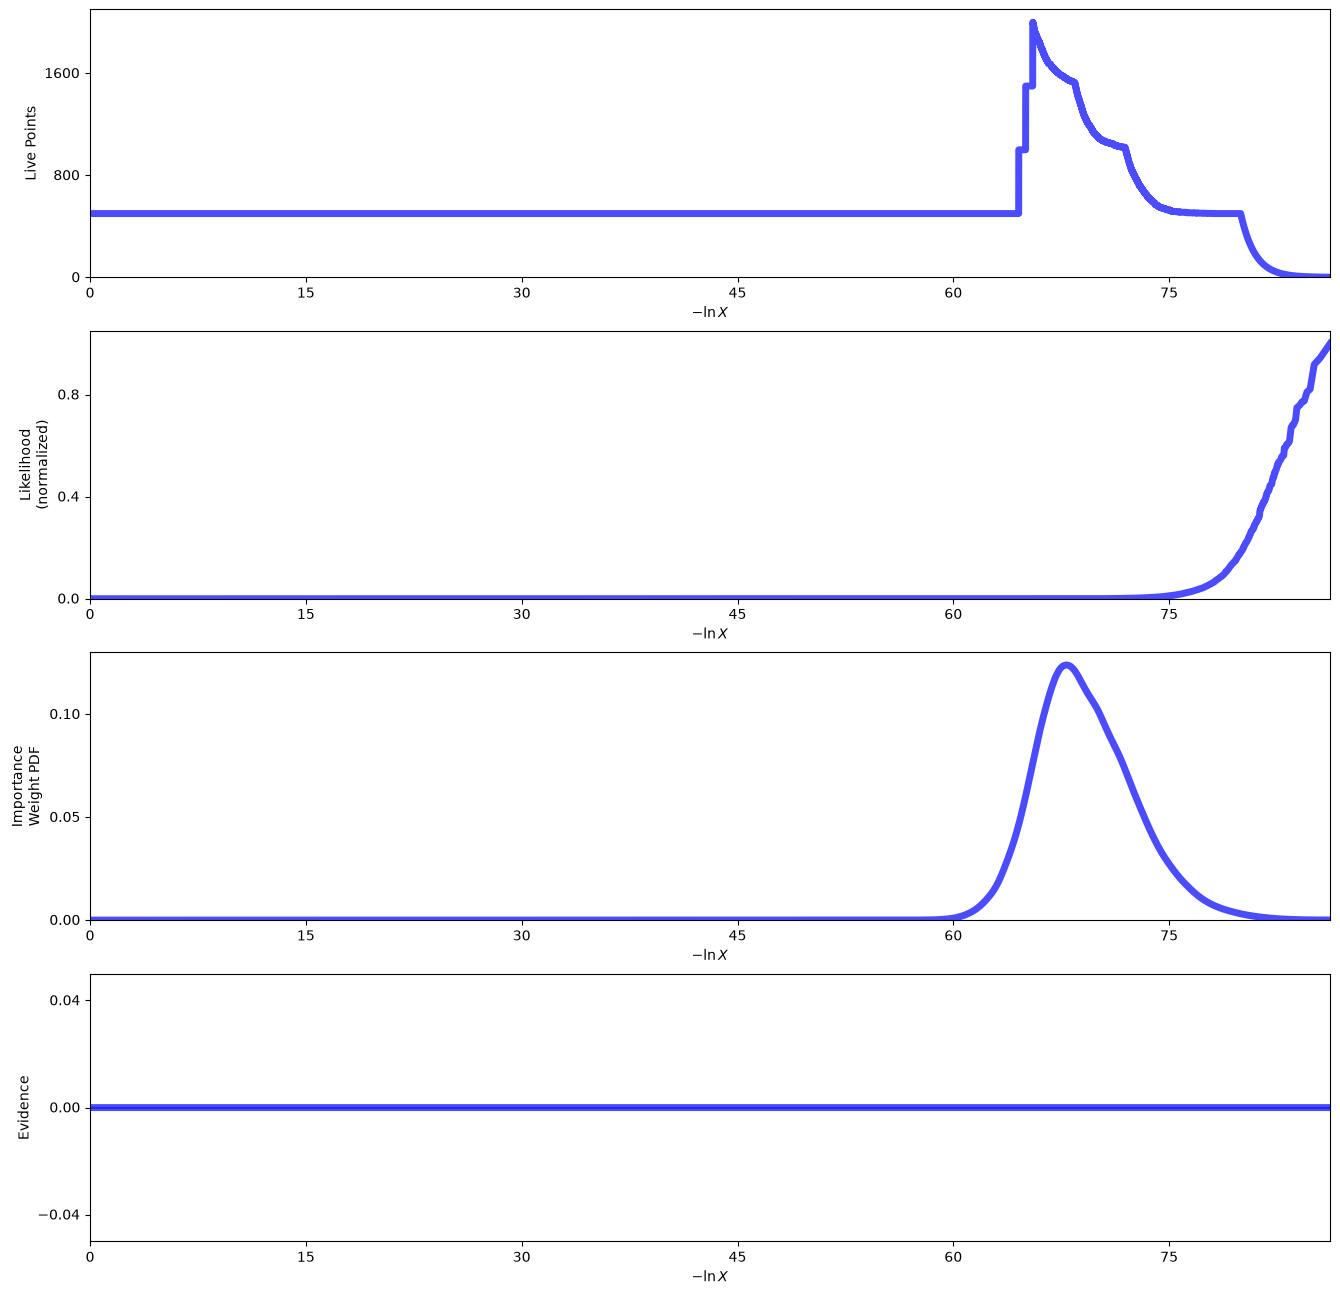

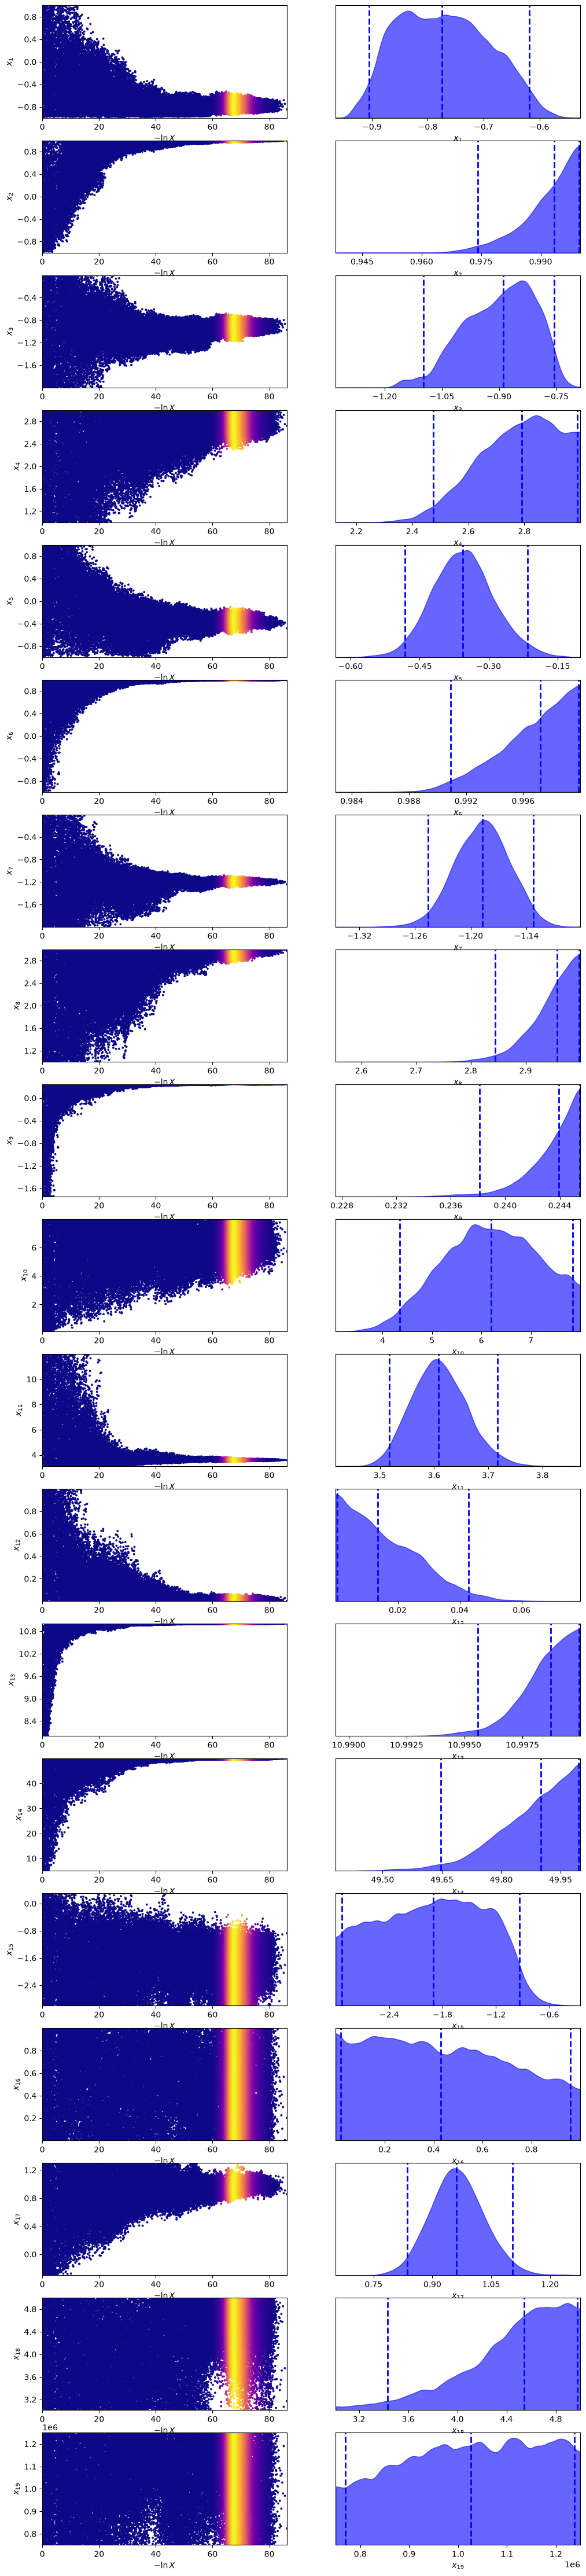

In [5]:
#diagnostic plot of the run, if the sampler has converged, the number of live points and weights should go to zero
#we can see this sampler has coverged correctly

print("number of sampling iterations = ", resu.niter)

from dynesty import plotting as dyplot

%matplotlib inline

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(resu)

# Plot traces and 1-D marginalized posteriors.
tfig, taxes = dyplot.traceplot(resu)

plt.show()

In [19]:
#--- LeoII setup: numbers from the run, radial grid, style helpers ---------------------------

s1flat = resu.samples_equal()      # equal-weight posterior samples, shape (Nsamp, ndims)


print('N tracers        = %d   (LOS only)' % len(rLOS))
print('R_proj range     = %.4f - %.4f kpc   (R_half = %.4f kpc)' % (rLOS.min(), rLOS.max(), Rhalf))
print('ndims            = %d' % ndims)
print('iterations       = %d,  calls = %d,  eff = %.2f%%'
      % (resu.niter, resu.ncall.sum(), 100*resu.niter/resu.ncall.sum()))
print('log Z            = %.3f +/- %.3f' % (resu.logz[-1], resu.logzerr[-1]))
print('max log L        = %.3f' % resu.logl.max())
print('equal-wt samples = %d' % len(s1flat))

# parameter order in Theta (individual == True, so ndims = 18, or 19 with Mstar)
s1labs = ['bet0_t', 'betinf_t', 'log rbeta', 'eta',            # 0-3  2nd-order anisotropy
          "bet0_t'", "betinf_t'", "log rbeta'", "eta'",        # 4-7  4th-order anisotropy
          'log rp', 'alp_p', 'bet_p', 'gam_p',                 # 8-11 tracer light profile
          'logM200', 'c200', 'log rc', 'n', 'log rt', 'delta'] # 12-17 coreNFWtides

# Mstar (index 18) is sampled linearly in Msun, so show it in units of 1e6 Msun to
# keep the column widths of the table; everything else is printed as sampled.
s1scale = np.ones(ndims)
if Mstar != 0.0:
    s1labs.append('Mstar/1e6')                                 # 18   stellar mass
    s1scale[-1] = 1.0e-6

print('\n%-11s %9s %9s %9s %9s   %s' % ('param', 'mean', '16%', '50%', '84%', 'prior'))
for i, l in enumerate(s1labs):
    sc = s1scale[i]
    mean = np.mean(s1flat[:, i])*sc
    q = np.percentile(s1flat[:, i], [16, 50, 84])*sc
    lo, hi = minarr[i]*sc, maxarr[i]*sc
    flag = ''
    if q[0] - lo < 0.05*(hi-lo): flag += '  <- at lower prior edge'
    if hi - q[2] < 0.05*(hi-lo): flag += '  <- at upper prior edge'
    print('%-11s %9.3f %9.3f %9.3f %9.3f   [%.2f, %.2f]%s'
          % (l, mean, q[0], q[1], q[2], lo, hi, flag))

#--- plotting setup --------------------------------------------------------------------------
col, al = 'mediumseagreen', 0.7
leg = r'LeoII (%d stars, LOS only)(%d pm stars)' % (len(rLOS), len(rPM))
Rmax_dat = np.max(rLOS)                                  # outermost member, 90 pc
Ra = np.logspace(np.log10(1.0e-2), np.log10(4), 300)   # 1 pc - 300 pc
fsl = fst = 26*1.3

plt.style.use('default')
from matplotlib import rc
rc('axes', linewidth=1)
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
rc('font', weight='bold')


def band(samples_2d, levels=(0.0275, 0.16, 0.5, 0.84, 0.975)):
    """95%, 68% and median envelopes of an (Nsamp, Nr) array of profiles."""
    return np.percentile(samples_2d, 100*np.array(levels), axis=0)


def pretty_ax(ax, ylo, yhi, xlo=Ra.min(), xhi=Ra.max(), logy=False):
    """Fornax-notebook axis styling, plus R_half and an 'outside the data' shading."""
    ax.axvline(Rhalf, ls='--', color='gray', lw=3.0, zorder=0)
    #ax.axvspan(Rmax_dat, xhi, color='0.85', alpha=0.6, zorder=-5)   # no tracers out here
    ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.tick_params(labelsize=fst)
    ax.tick_params('both', length=8.5, width=2.5, which='major', direction='out')
    ax.tick_params('both', length=5, width=1.8, which='minor', direction='out')
    axx, axy = ax.secondary_yaxis('right'), ax.secondary_xaxis('top')
    for sec in (axx, axy):
        sec.tick_params('both', length=8.5, width=2.5, which='major', direction='in')
        sec.tick_params('both', length=5, width=1.8, which='minor', direction='in')
    axx.set_yticklabels([])
    axy.set_xticklabels([])
    for s in ['top', 'bottom', 'left', 'right']:
        ax.spines[s].set_linewidth(2.5)


N tracers        = 175   (LOS only)
R_proj range     = 0.0355 - 0.7418 kpc   (R_half = 0.1760 kpc)
ndims            = 19
iterations       = 47487,  calls = 1775864,  eff = 2.67%
log Z            = -53344.546 +/- 0.276
max log L        = -53268.672
equal-wt samples = 47487

param            mean       16%       50%       84%   prior
bet0_t         -0.771    -0.859    -0.774    -0.682   [-1.00, 1.00]
betinf_t        0.992     0.985     0.993     0.998   [-1.00, 1.00]  <- at upper prior edge
log rbeta      -0.900    -0.999    -0.889    -0.804   [-2.00, 0.00]
eta             2.776     2.625     2.791     2.927   [1.00, 3.00]  <- at upper prior edge
bet0_t'        -0.355    -0.421    -0.356    -0.289   [-1.00, 1.00]
betinf_t'       0.997     0.994     0.997     0.999   [-1.00, 1.00]  <- at upper prior edge
log rbeta'     -1.188    -1.217    -1.187    -1.158   [-2.00, 0.00]
eta'            2.948     2.908     2.958     2.988   [1.00, 3.00]  <- at upper prior edge
log rp          0.243     0.

In [7]:
# rc('text', usetex=True) above shells out to latex + dvipng. The texlive-core
# in the conda env is binaries only (no macros, no dvipng, so it cannot build
# latex.fmt) and it sits ahead of everything else on PATH, which is what raised
# "I can't find the format file `latex.fmt'". TinyTeX in $HOME is the working
# install, so put it first.
import os
_texbin = os.path.expanduser('~/.TinyTeX/bin/x86_64-linux')
if not os.environ['PATH'].startswith(_texbin):
    os.environ['PATH'] = _texbin + os.pathsep + os.environ['PATH']


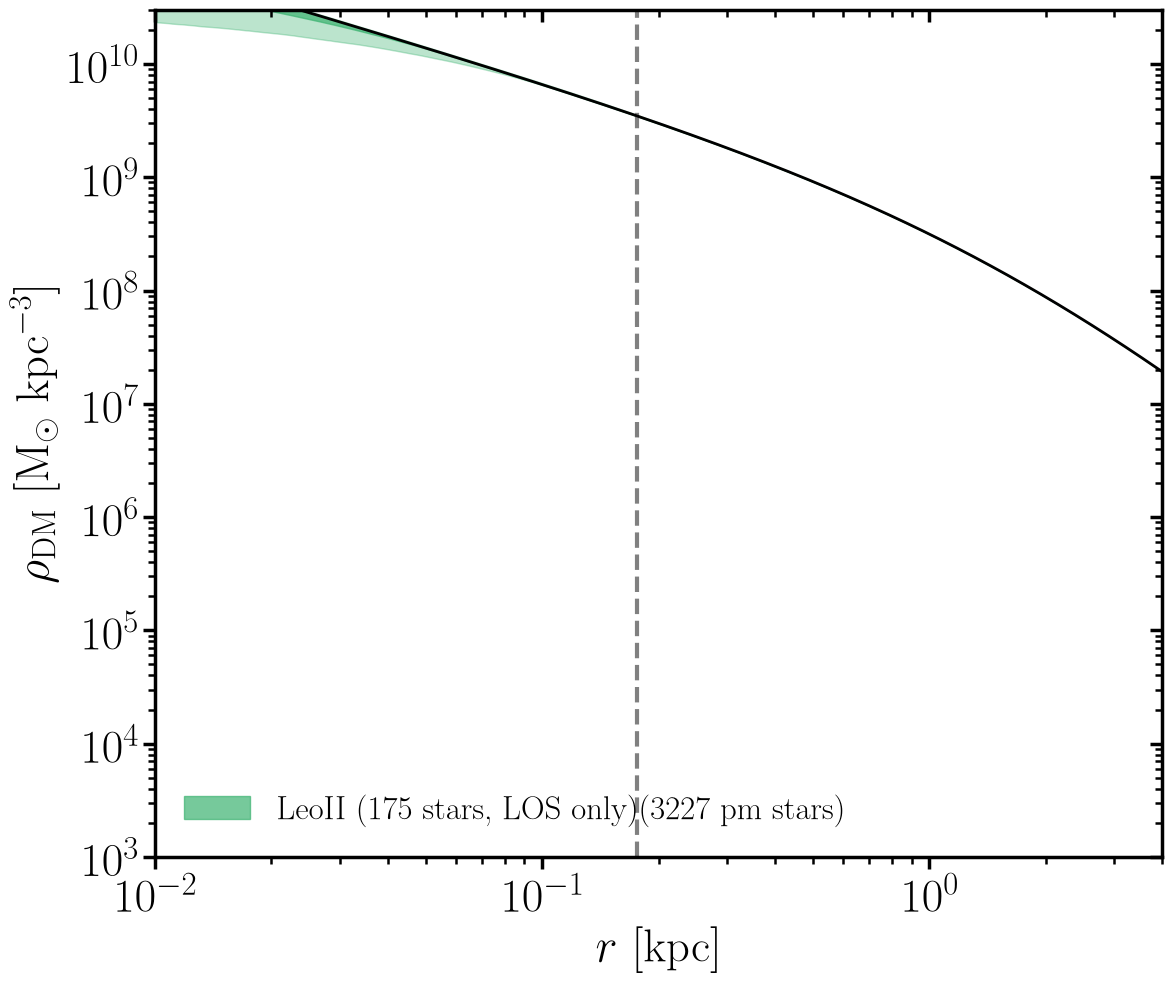

log10 rho_DM(R_half) = 9.54 -0.00 +0.00  [Msun/kpc^3]


In [20]:
#--- LeoII: DM density profile -------------------------------------------------------------

upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:                    # exponentiate the log-sampled parameters
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]  # coreNFWtides
    upacs[k, :] = corenfw_tides_den(Ra, *Mppars)

b = band(upacs)

fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)   # 95%
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)  # 68%
ax.plot(Ra, b[2], color='k', lw=2.0)                               # median
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\rho_{\rm DM}$ [M$_{\odot}$ kpc$^{-3}$]', fontsize=fsl)
pretty_ax(ax, 1e3, 3e10, logy=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.savefig(str(diro + 'Plots/den_leoII.pdf'), bbox_inches='tight')
plt.show()

q = np.percentile(np.log10(upacs[:, np.argmin(np.abs(Ra - Rhalf))]), [16, 50, 84])
print('log10 rho_DM(R_half) = %.2f -%.2f +%.2f  [Msun/kpc^3]' % (q[1], q[1]-q[0], q[2]-q[1]))


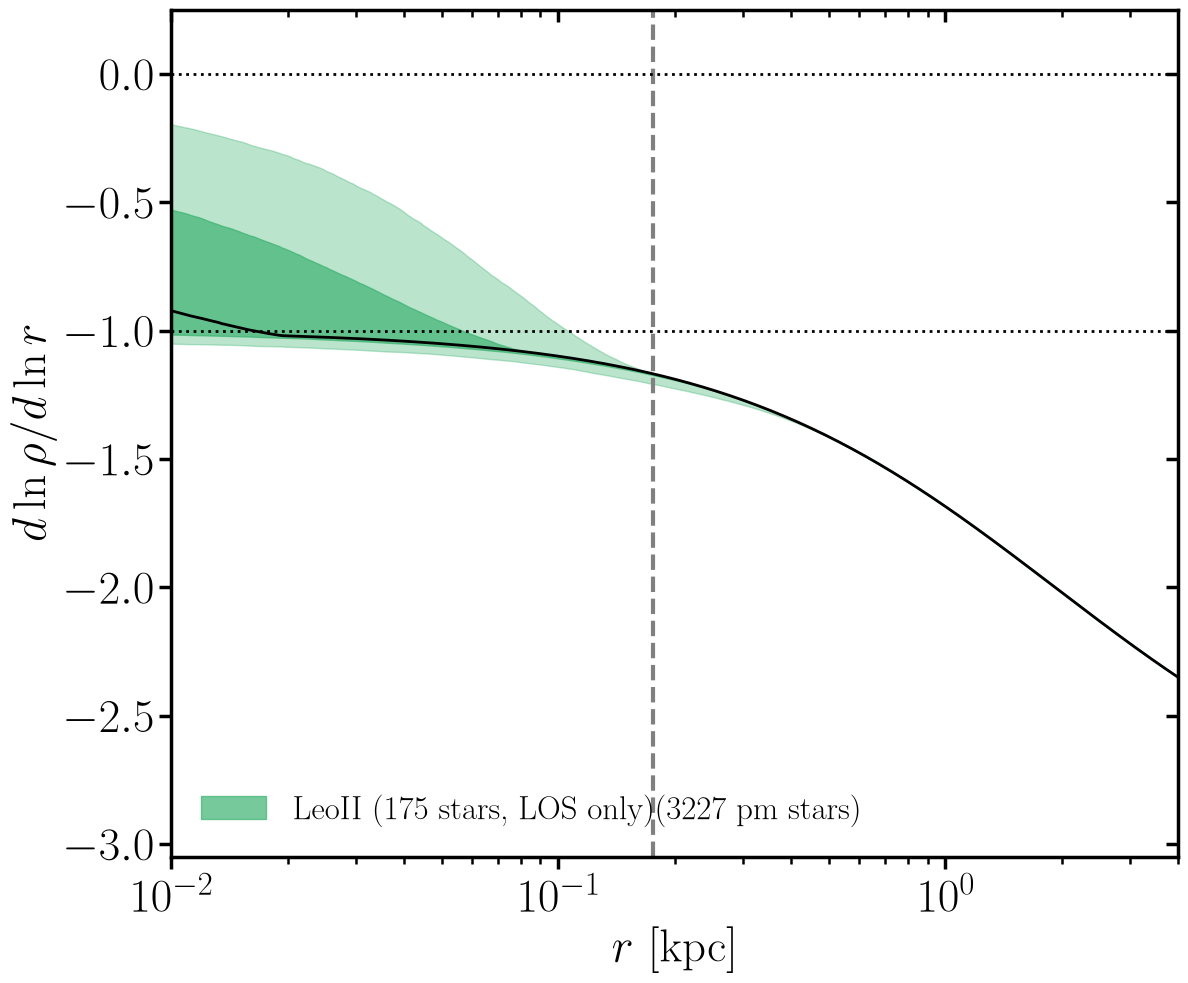

dlnrho/dlnr at r = 0.0440 kpc : -1.04 -0.01 +0.12
dlnrho/dlnr at r = 0.0880 kpc : -1.09 -0.01 +0.00
dlnrho/dlnr at r = 0.1760 kpc : -1.17 -0.01 +0.00


In [21]:
#--- LeoII: logarithmic density slope (the cusp/core diagnostic) ----------------------------

upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]
    upacs[k, :] = corenfw_tides_dlnrhodlnr(Ra, *Mppars, dx=1e-5)

b = band(upacs)

fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(-1.0, ls=':', color='k', lw=2.0)      # NFW cusp
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # perfect core
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'${d \ln \rho} / {d \ln r}$', fontsize=fsl)
pretty_ax(ax, -3.05, 0.25)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.savefig(str(diro + 'Plots/slope_LeoII.pdf'), bbox_inches='tight')
plt.show()

for rr in [Rhalf/4, Rhalf/2, Rhalf]:
    q = np.percentile(upacs[:, np.argmin(np.abs(Ra - rr))], [16, 50, 84])
    print('dlnrho/dlnr at r = %.4f kpc : %.2f -%.2f +%.2f' % (rr, q[1], q[1]-q[0], q[2]-q[1]))


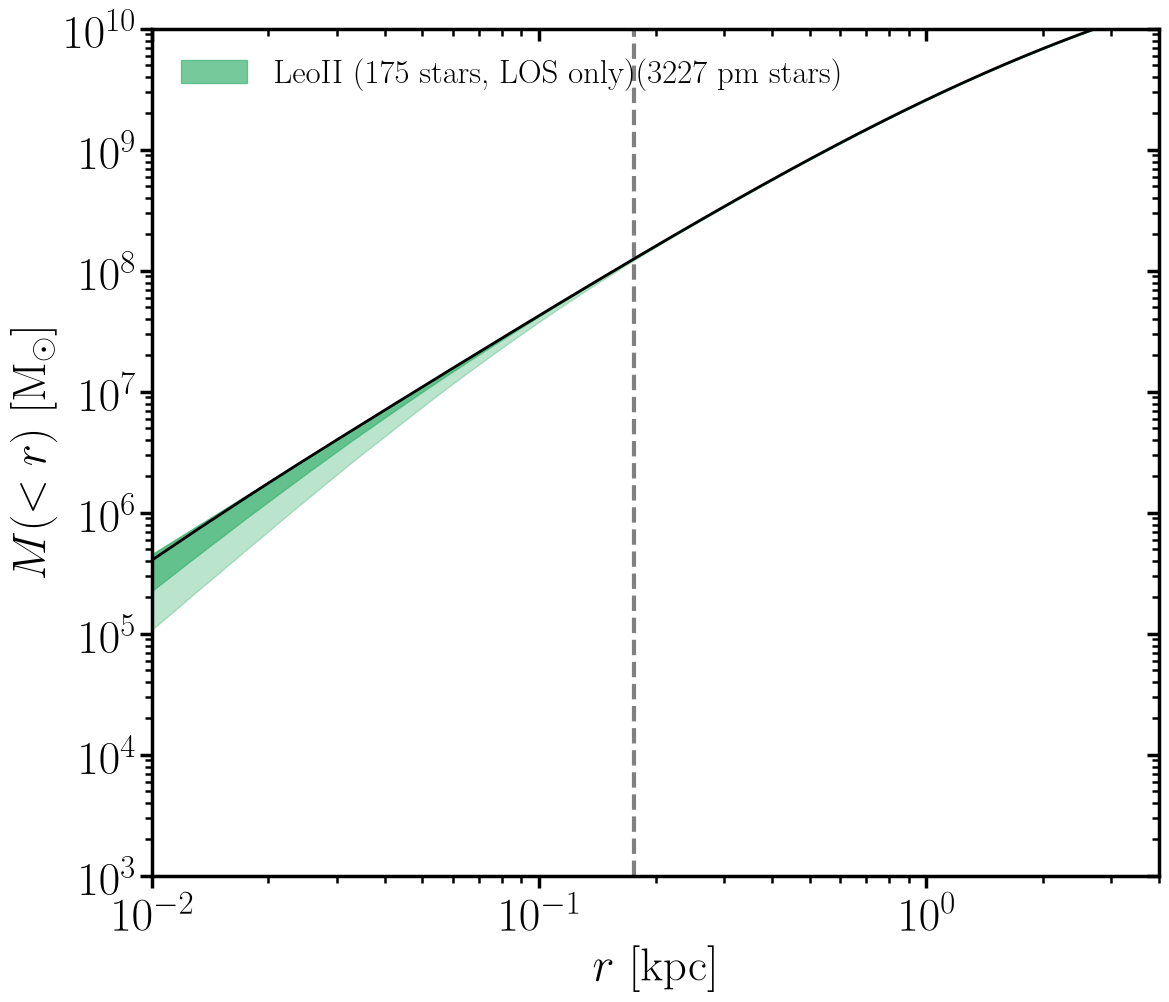

log10 M(<R_half) = 8.10 -0.00 +0.00  [Msun]


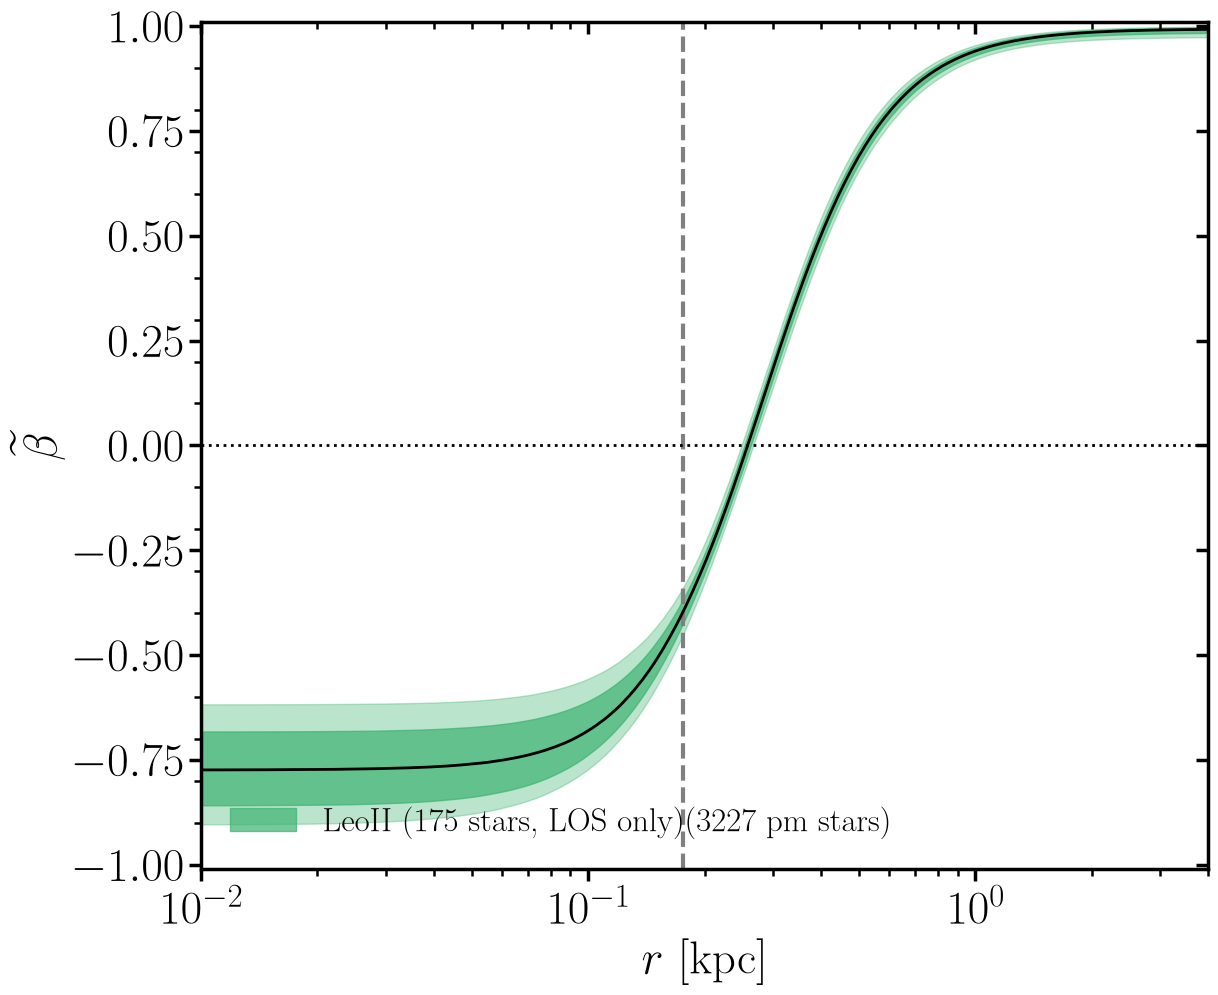

betat(R_half) = -0.40 -0.03 +0.03


In [22]:
#--- LeoII: enclosed mass, and the symmetrised anisotropy -----------------------------------

# enclosed mass
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]
    upacs[k, :] = corenfw_tides_mass(Ra, *Mppars)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$M(<r)$ [M$_{\odot}$]', fontsize=fsl)
pretty_ax(ax, 1e3, 1e10, logy=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='upper left')
plt.savefig(str(diro + 'Plots/mass_LeoII.pdf'), bbox_inches='tight')
plt.show()

q = np.percentile(np.log10(upacs[:, np.argmin(np.abs(Ra - Rhalf))]), [16, 50, 84])
print('log10 M(<R_half) = %.2f -%.2f +%.2f  [Msun]' % (q[1], q[1]-q[0], q[2]-q[1]))

# symmetrised anisotropy  betat = beta / (2 - beta)
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')

plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))


In [23]:
#--- LeoII: projected sigma_LOS and kurtosis (LOS only -> sigp_k, not sigp_prop_k) ----------

nls = 500        # number of random posterior draws; raise for smoother envelopes
s1file = 'LeoII'

upacsl = np.zeros((nls, len(Ra)))    # sigma_LOS
upacslk = np.zeros((nls, len(Ra)))   # kappa_LOS

for it in range(nls):
    theta = np.copy(s1flat[np.random.randint(len(s1flat))])

    # symmetrised -> ordinary anisotropy, 2nd and 4th order
    theta[0] = 2.0*theta[0]/(1 + theta[0])
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    theta[4] = 2.0*theta[4]/(1 + theta[4])
    theta[5] = 2.0*theta[5]/(1 + theta[5])
    for i in logthis:
        theta[i] = 10**theta[i]

    surc = theta[2*n_betpars:2*n_betpars+nu_components]     # tracer light profile
    if individual == True:
        surc = np.append(np.array([1.0]), surc)             # rho0 is unconstrained, set to 1

    rhobs = alpbetgamden(nu_rad, *surc)
    sobs = alpbetgamsurf(nu_rad, *surc, bar_pnts)

    def baranr(r):                                          # tracer 3D density
        return np.interp(r, nu_rad, rhobs, right=1e-30)

    def barsurf(r):                                         # tracer 2D density
        return np.interp(r, nu_rad, sobs, right=1e-30)

    Mpars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]

    def M(r, Mparsu):                                       # Mstar = 0 for Segue 1
        M200, c, rc, n, rt, delta = Mparsu
        return corenfw_tides_mass(r, M200, c, rc, n, rt, delta)

    Sigout, los2, kl, neg = sigp_k(np.array([1.0]), Ra, baranr, barsurf, M, beta, betaf,
                                   Mpars, theta[:4], theta[4:8], rmin, rmax, nonn=rcn)

    upacsl[it, :] = los2**0.5/1e3
    upacslk[it, :] = kl

np.savetxt(str(diro + s1file + '_sl.txt'), band(upacsl))
np.savetxt(str(diro + s1file + '_kl.txt'), band(upacslk))
print('done -> ' + diro + s1file + '_{sl,kl}.txt')


done -> /gpfs/home/jd925/GravSphere2/Output/LeoII_pm/LeoII_{sl,kl}.txt


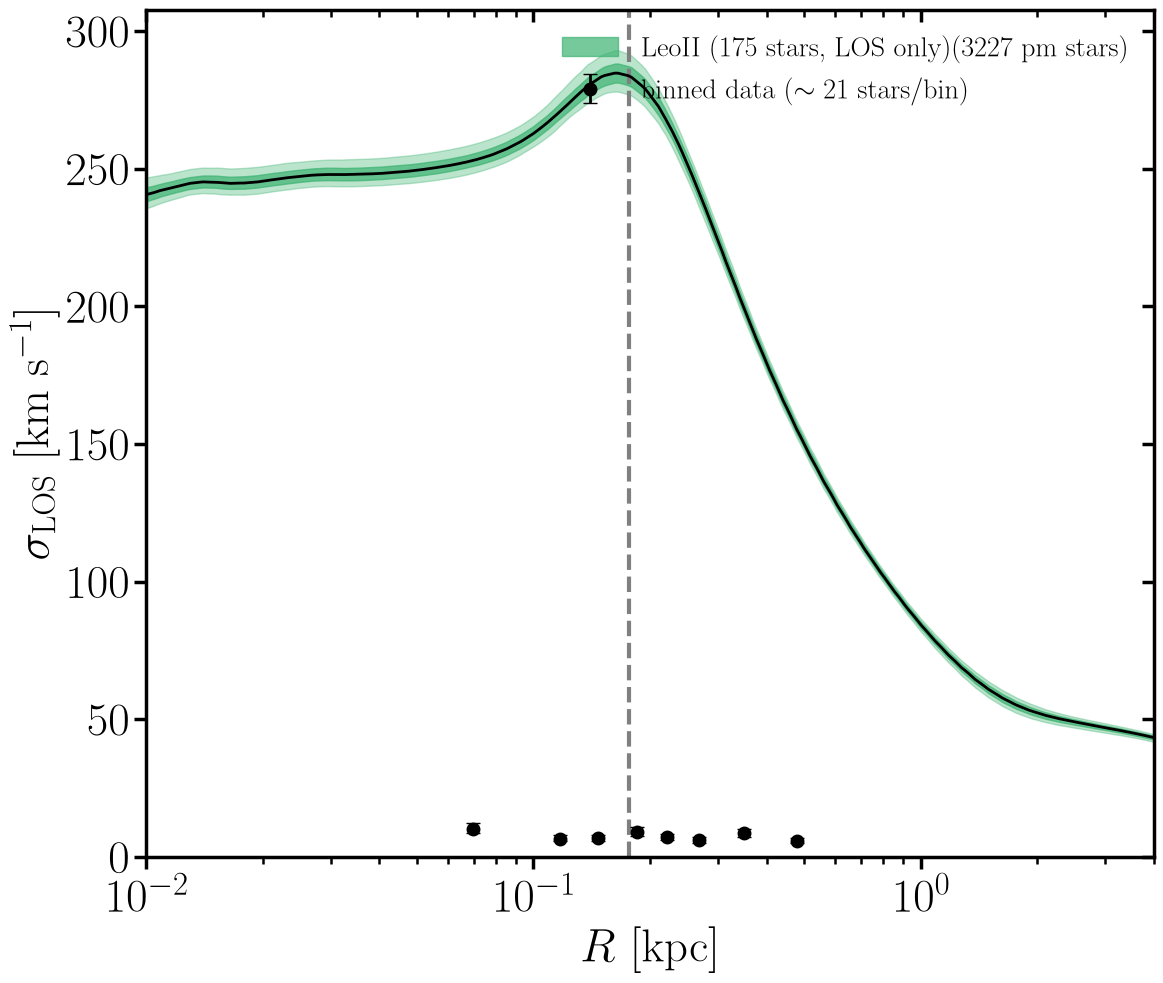

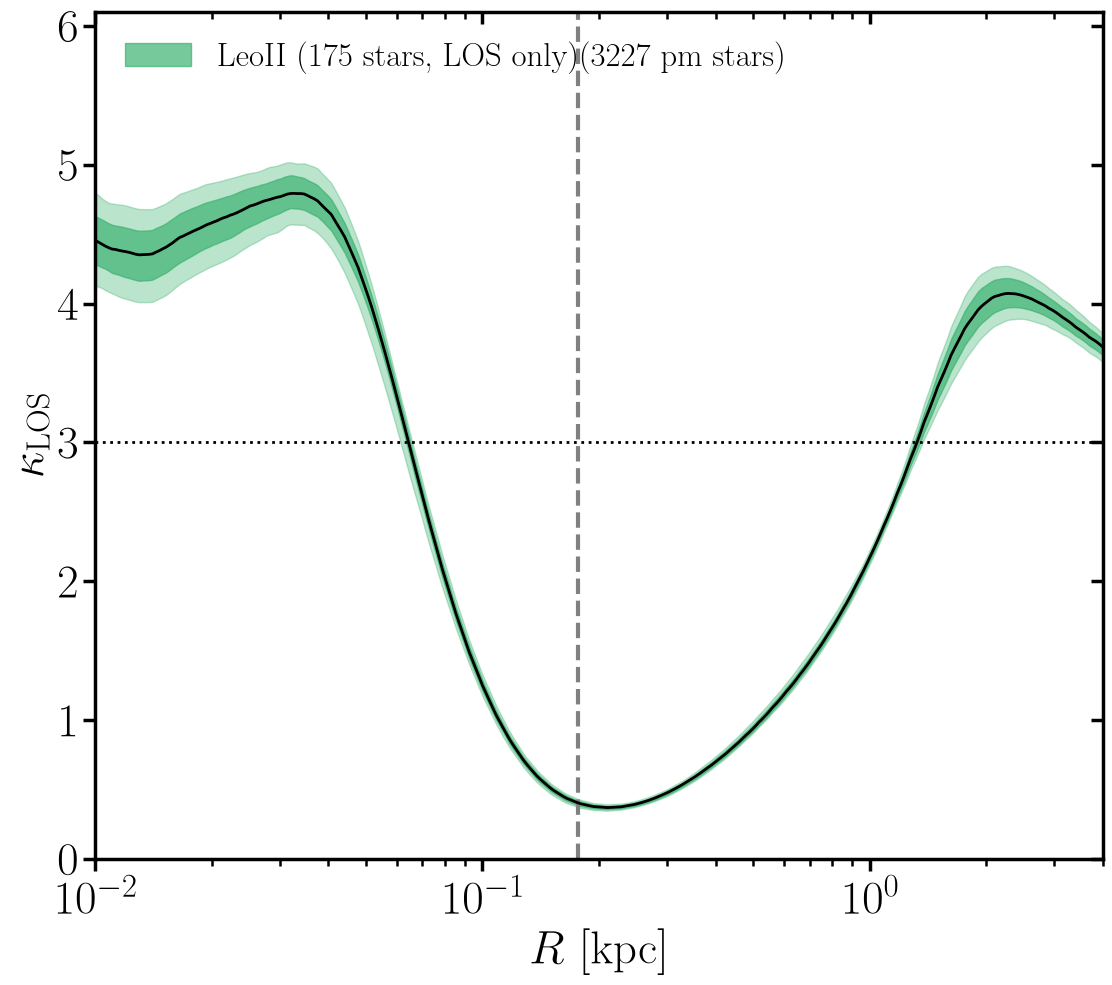

In [24]:
#--- LeoII: sigma_LOS and kappa_LOS, with binned data over-plotted --------------------------

nbin = 8
sgrid = np.linspace(0.05, 25.0, 600)


def sig_ml(v, e):
    """16/50/84 of sigma in one bin: Gaussian likelihood with per-star errors,
    systemic velocity profiled out on a grid (a plain moment estimate goes
    imaginary here because the errors exceed the dispersion)."""
    mug = np.linspace(v.min()-5, v.max()+5, 200)
    var = sgrid[:, None, None]**2 + e[None, None, :]**2
    d2 = (v[None, None, :] - mug[None, :, None])**2
    lnL = -0.5*np.sum(d2/var + np.log(2*np.pi*var), axis=2)
    L = np.exp(lnL - lnL.max()).sum(axis=1)
    return np.interp([0.16, 0.5, 0.84], np.cumsum(L)/np.sum(L), sgrid)


idx = np.argsort(rLOS)
Rs, vs, es = rLOS[idx], vLOS[idx], vLOS_err[idx]
groups = np.array_split(np.arange(len(Rs)), nbin)
Rb = np.array([Rs[g].mean() for g in groups])
qb = np.array([sig_ml(vs[g], es[g]) for g in groups])
sb = qb[:, 1]
sberr = np.vstack([sb - qb[:, 0], qb[:, 2] - sb])

# sigma_LOS
b = np.loadtxt(str(diro + s1file + '_sl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.errorbar(Rb, sb, yerr=sberr, fmt='o', color='k', ms=9, capsize=5, lw=2.0, zorder=5,
            label=r'binned data ($\sim %d$ stars/bin)' % (len(Rs)//nbin))
ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
pretty_ax(ax, 0.0, np.max(b[4])*1.05)
ax.legend(frameon=False, fontsize=fsl*0.6, loc='upper right')
plt.savefig(str(diro + 'Plots/sl_LeoII.pdf'), bbox_inches='tight')
plt.show()

# kappa_LOS
b = np.loadtxt(str(diro + s1file + '_kl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(3.0, ls=':', color='k', lw=2.0)       # Gaussian
ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\kappa_{\rm LOS}$', fontsize=fsl)
pretty_ax(ax, 0.0, 6.1)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='upper left')
plt.savefig(str(diro + 'Plots/kl_LeoII.pdf'), bbox_inches='tight')
plt.show()


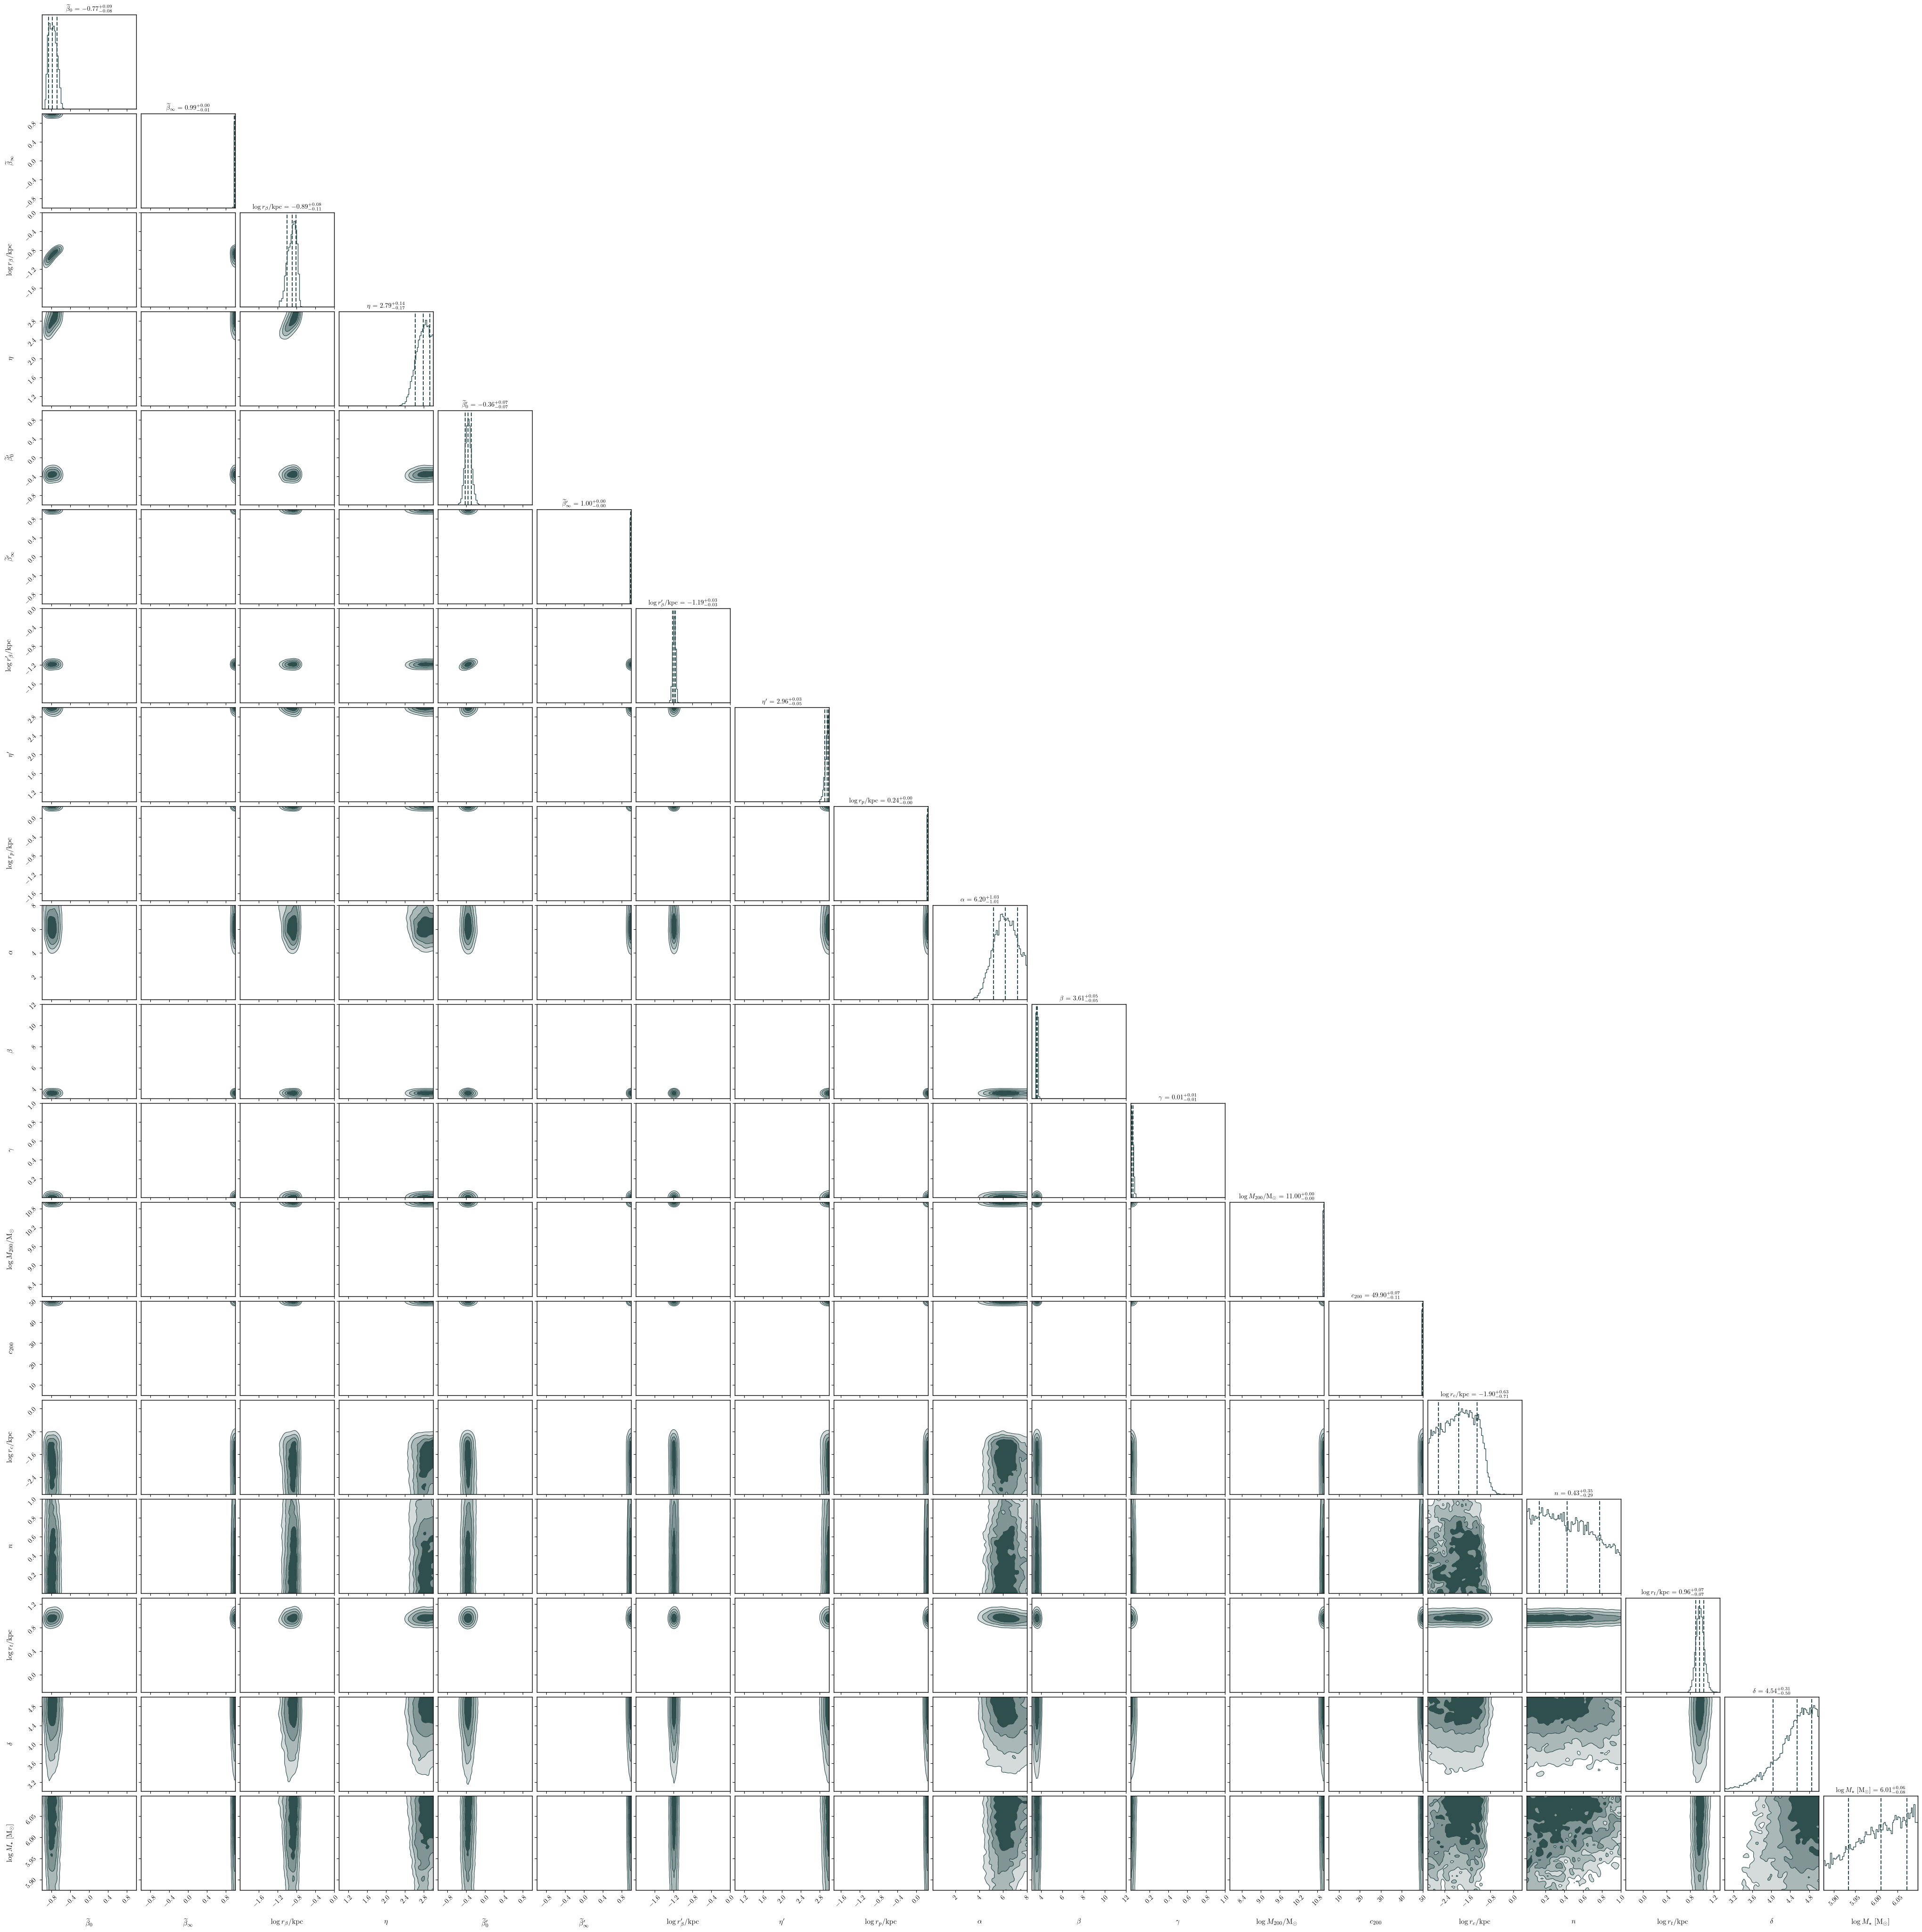

In [25]:
#--- LeoII: corner plot ----------------------------------------------------------------------

import corner

labes = [r'$\widetilde \beta_0$', r'$\widetilde \beta_{\infty}$',
         r'$\log r_{\beta}$/kpc', r'$\eta$',
         r"$\widetilde \beta_0'$", r"$\widetilde \beta_{\infty}'$",
         r"$\log r_{\beta}'$/kpc", r"$\eta'$",
         r'$\rho_{p}$/kpc$^{-3}$', r'$r_p$/kpc',
         r'$\alpha$', r'$\beta$', r'$\gamma$',
         r'$\log M_{200}$/M$_{\odot}$', r'$c_{200}$',
         r'$\log r_c$/kpc', r'$n$', r'$\log r_t$/kpc', r'$\delta$']

if individual == True:
    labes[9] = r'$\log r_p$/kpc'   # log-priors on rp in the individual-tracer case
    labes.pop(2*n_betpars)         # rho_p is not a free parameter, drop its label

levs = (1 - np.exp(-(1)**2/2), 1 - np.exp(-(1.5)**2/2),
        1 - np.exp(-(2.0)**2/2), 1 - np.exp(-(2.5)**2/2))

seq = resu.samples_equal()
rng = [(minarr[i], maxarr[i]) for i in range(ndims)]   # show the full prior box:
                                                       # flat-topped 1D panels = prior-limited
if Mstar != 0.0:
    # Mstar is the last dimension and is sampled linearly in [Mstar_min, Mstar_max];
    # plot it in log, and put its prior box in log too, or corner histograms the
    # log-samples inside a linear-Msun range and gets an empty 2D histogram.
    labes.append(r'$\log M_{\star}$ [M$_{\odot}$]')
    seq[:, -1] = np.log10(seq[:, -1])
    rng[-1] = (np.log10(minarr[-1]), np.log10(maxarr[-1]))

fig = corner.corner(seq, labels=labes,
    quantiles=(0.16, 0.5, 0.84), label_kwargs=dict(fontsize=11),
    show_titles=True, title_fmt='.2f', use_math_text=True, title_kwargs=dict(fontsize=10),
    bins=70, smooth=1.4, fill_contours=True, color='darkslategray',
    plot_datapoints=False, plot_density=False,
    contour_kwargs={'linewidths': 0.8}, levels=levs,
    range=rng)

plt.savefig(str(diro + 'Plots/corner_LeoII.pdf'), bbox_inches='tight')
plt.show()


# Plots for comparison with simulations

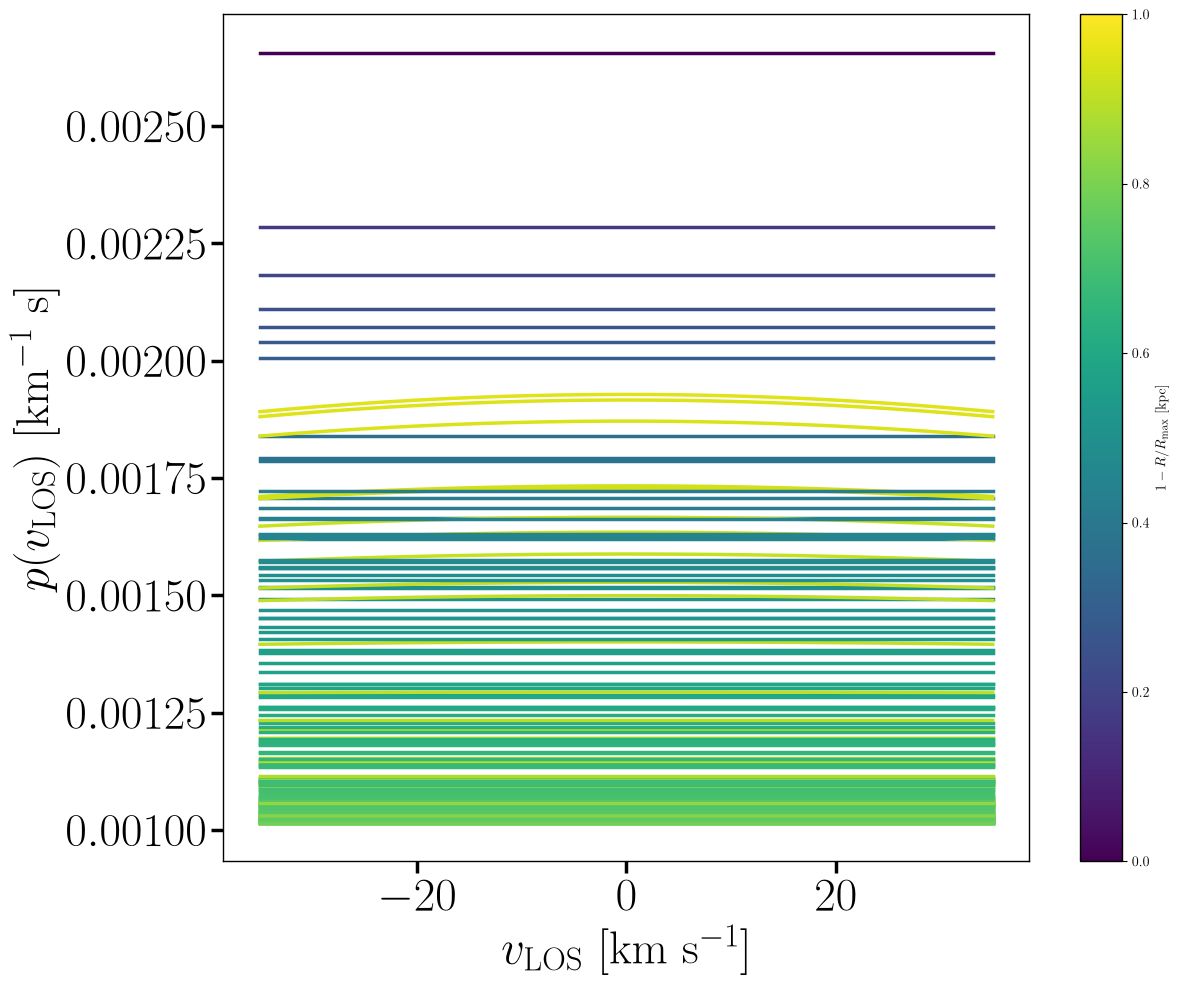

In [14]:
#--- LeoII: LOS velocity distributions from Eqs. A.1 / A.6 ---------------------------------
from scipy.special import ndtr, erfc          # ndtr = Phi, the standard normal CDF (Eq. A.2)

aguess = np.linspace(1e-6, 100, 10**4)

def get_a(kurt):

    if kurt < 3.0:
        kg = 3.0 - (2*aguess**4/15)*(1 + aguess**2/3)**(-2.0)              # A.4
        return np.interp(kurt, kg[::-1], aguess[::-1])
    else:
        kg = 3.0 + 12*aguess**4*(2*aguess**2 + 1)**(-2.0)                      # A.7
        return np.interp(kurt, kg, aguess)

def fvel(v, sigma, kurt, err):
    
    w = np.asarray(v, dtype=float)/sigma
    s = err/sigma

    if abs(kurt - 3.0) < 1e-4:                                       # a -> 0: Gaussian limit
        t = np.sqrt(1.0 + s**2)
        return np.exp(-0.5*(w/t)**2)/(np.sqrt(2*np.pi)*t)/sigma
    
    a = get_a(kurt)
    if kurt < 3.0:
        b = np.sqrt(1.0 + a**2/3.0)                                  # A.5
        t = np.sqrt(1.0 + b**2*s**2)                                 # A.3
        f = b/(2*a)*(ndtr((b*w + a)/t) - ndtr((b*w - a)/t))          # A.1
    else:
        b = np.sqrt(2.0*a**2 + 1.0)                                  # A.8
        t = np.sqrt(1.0 + b**2*s**2)                                 # A.3
        f = b/(4*a)*(np.exp((t**2 - 2*a*b*w)/(2*a**2))*erfc((t**2 - a*b*w)/(np.sqrt(2)*t*a))
                   + np.exp((t**2 + 2*a*b*w)/(2*a**2))*erfc((t**2 + a*b*w)/(np.sqrt(2)*t*a)))  # A.6
    return f/sigma

n_prof = len(rLOS)
Rshow  = rLOS
R_max = np.max(Rshow)

sl     = np.loadtxt(str(diro + s1file + '_sl.txt'))[2]
kl     = np.loadtxt(str(diro + s1file + '_kl.txt'))[2]
sig_at = np.interp(Rshow, Ra, sl)
kur_at = np.interp(Rshow, Ra, kl)

star_data = np.loadtxt('/gpfs/home/jd925/GravSphere2/Data/LeoII/LeoII_Rproj_vlos_vloserr.txt')

vLOS_err = star_data[:, 2]

vv = np.linspace(-35.0, 35.0, 1000)
fig, ax = plt.subplots(figsize=(13, 11))
for i, (R, s, k) in enumerate(zip(Rshow, sig_at, kur_at)):
    err = vLOS_err[i]
    ax.plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
            ls='-', label=r'$R = %.1f$ pc' % (1e3*R))
ax.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', label=r'$1 - R/R_{\max}$ [kpc]')
ax.set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
ax.set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=fsl)
ax.tick_params(labelsize=fst)
ax.tick_params('both', length=8.5, width=2.5, which='major', direction='out')
#ax.legend(frameon=False, fontsize=fsl*0.45, ncol=2)
plt.savefig(str(diro + 'Plots/vdf_LeoII.pdf'), bbox_inches='tight')
plt.show()


R_proj range = 0.0355 - 0.7418 kpc   (R_half = 0.1760 kpc)


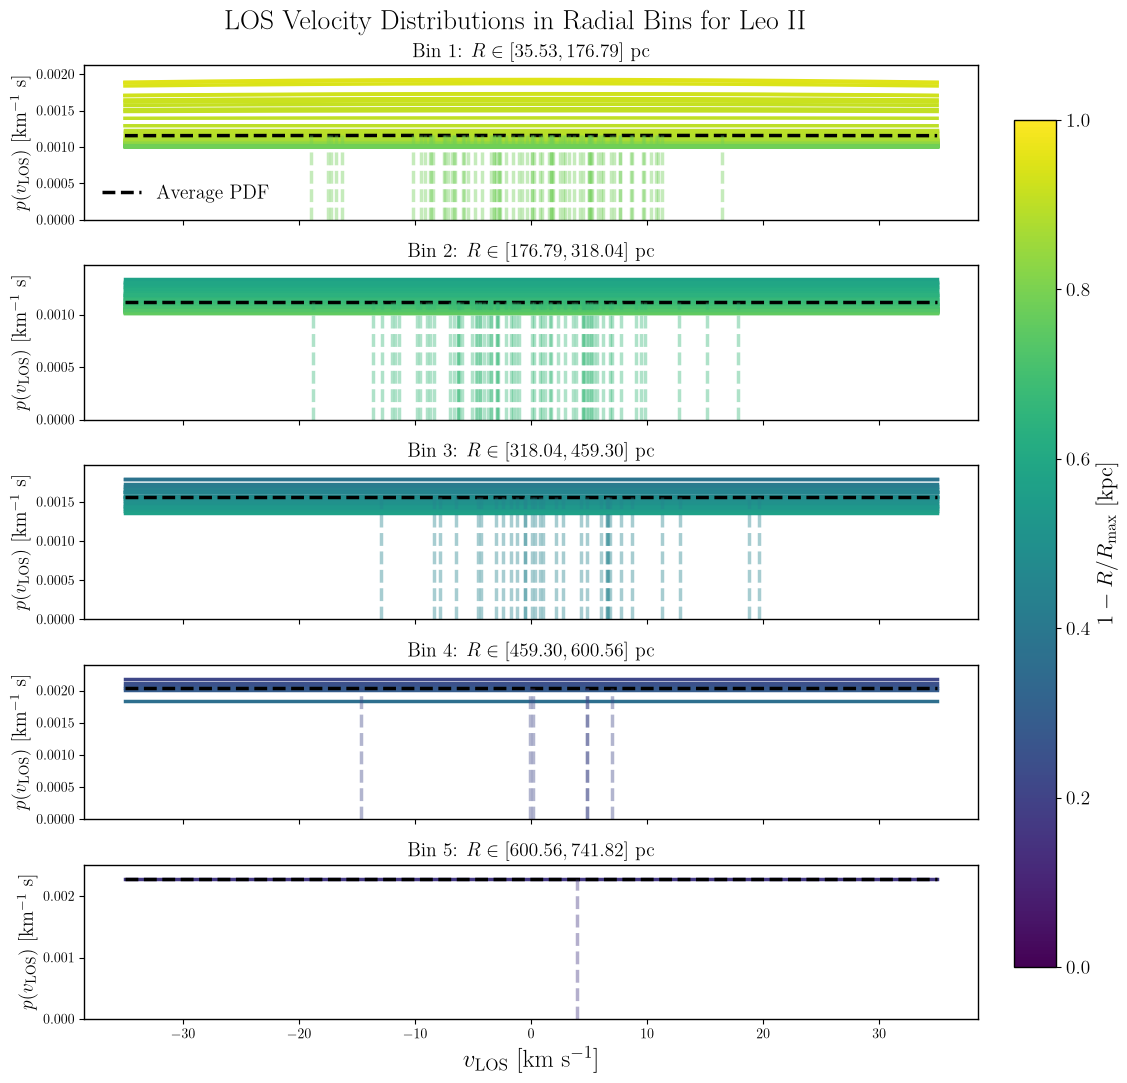

In [15]:
n_bins = 5

rLOS = star_data[:, 0]

print('R_proj range = %.4f - %.4f kpc   (R_half = %.4f kpc)' % (rLOS.min(), rLOS.max(), Rhalf))

bin_edges = np.linspace(rLOS.min(), rLOS.max(), n_bins + 1)

fig, ax = plt.subplots(5, 1, sharex=True, figsize=(13, 11))

for i in range(n_bins):
    mask = (rLOS >= bin_edges[i]) & (rLOS < bin_edges[i + 1])
    bin_rLOS = rLOS[mask]
    bin_vLOS = star_data[mask, 1]
    bin_vLOS_err = star_data[mask, 2]
    sig_at_bin = sig_at[mask]
    kur_at_bin = kur_at[mask]

    vv = np.linspace(-35.0, 35.0, 1000)

    max_pdf = 0.0

    for j, (R, s, k) in enumerate(zip(bin_rLOS, sig_at_bin, kur_at_bin)):
        err = bin_vLOS_err[j]
        ax[i].plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
                   ls='-')

        max_pdf = np.max([np.max(fvel(vv, s, k, err)), max_pdf])

    average_pdf = np.mean([fvel(vv, s, k, err) for s, k, err in zip(sig_at_bin, kur_at_bin, bin_vLOS_err)], axis=0)
    ax[i].plot(vv, average_pdf, color='k', lw=2.5, ls='--', label='Average PDF')

    for j in range(len(bin_vLOS)):

        ax[i].vlines(x = bin_vLOS[j], ymax = average_pdf[np.argmin(abs(vv - bin_vLOS[j]))], ymin = 0, color=plt.cm.viridis(1 - R/R_max), lw=2.5, ls='--', alpha = 0.4)


    ax[i].set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=14)
    ax[i].set_title(r'Bin %d: $R \in [%.2f, %.2f]$ pc' % (i + 1, bin_edges[i]*1000, bin_edges[i + 1]*1000), fontsize=14)
    if i == 0:
        ax[i].legend(frameon=False, fontsize=14)

    ax[i].set_ylim(0, max_pdf * 1.1)

ax[-1].set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=18)
fig.suptitle('LOS Velocity Distributions in Radial Bins for Leo II', fontsize=20, x=0.4)
cbar = fig.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', pad = -0.45)

cbar.ax.tick_params(labelsize=14) 
cbar.set_label(r'$1 - R/R_{\max}$ [kpc]', size=16)

plt.tight_layout()
plt.show()

    




r_p       1.754 -0.009 +0.005
alpha     6.196 -1.007 +1.032
beta      3.608 -0.049 +0.052
gamma     0.014 -0.010 +0.015


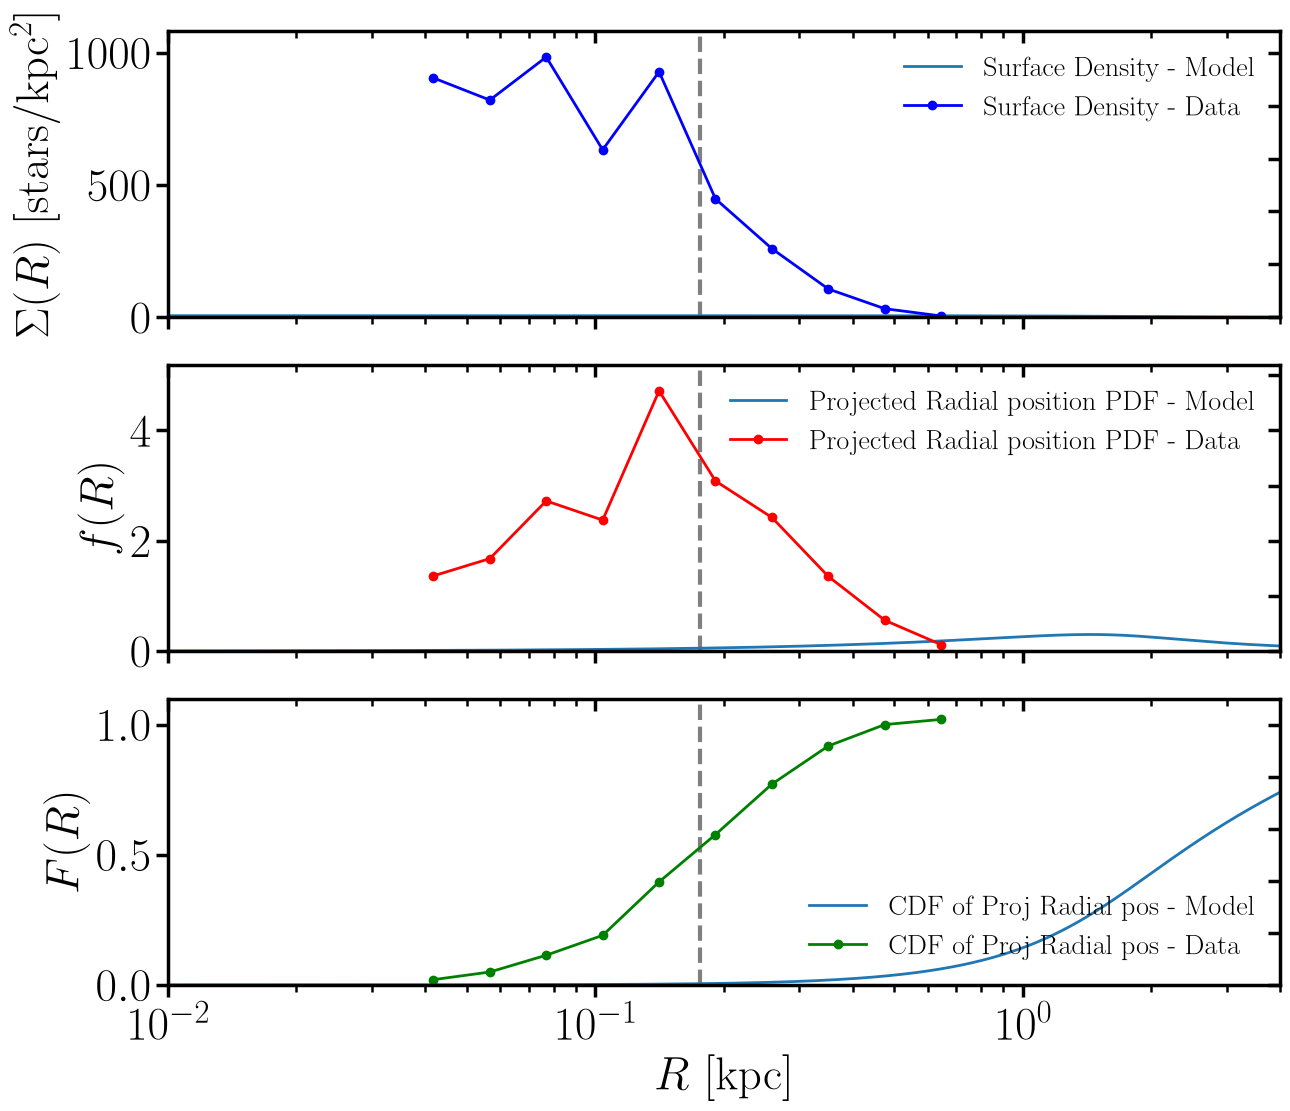

In [16]:
# Sigma model

from scipy.special import gamma as gammafn

i_nu = 2*n_betpars                      # = 8, first light-profile column

rp_s  = 10.0**s1flat[:, i_nu]           # kpc  (log-sampled -> exponentiate)
alp_s = s1flat[:, i_nu + 1]
bet_s = s1flat[:, i_nu + 2]
gam_s = s1flat[:, i_nu + 3]

r_p, alp_p, bet_p, gam_p = (np.median(rp_s), np.median(alp_s),
                            np.median(bet_s), np.median(gam_s))

for nm, x in [('r_p', rp_s), ('alpha', alp_s), ('beta', bet_s), ('gamma', gam_s)]:
    q = np.percentile(x, [16, 50, 84])
    print('%-6s %8.3f -%.3f +%.3f' % (nm, q[1], q[1]-q[0], q[2]-q[1]))


r = np.logspace(np.log10(1/1000), np.log10(10), 1000)

rrp = r/r_p

rho_p = 1

nu_star = rho_p / ((rrp)**gam_p * (1 + (rrp)**alp_p)**((bet_p - gam_p)/alp_p))

def Sigma_abg(R, rho0, r0, alp, bet, gam, npts=2000, zmax=200.0):
    R = np.atleast_1d(R)
    z = np.logspace(-6, np.log10(zmax), npts)[None, :]      # kpc
    rr = np.sqrt(R[:, None]**2 + z**2)
    return 2.0*np.trapezoid(alpbetgamden(rr, rho0, r0, alp, bet, gam), z, axis=1)


def abg_normmass(r0, alp, bet, gam, rho0=1.0):
    return (4*np.pi*rho0*r0**3 * gammafn((bet - 3)/alp) * gammafn((3 - gam)/alp)
            / (gammafn((bet - gam)/alp) * alp))

N_stars = len(rLOS)
rho_p   = N_stars / abg_normmass(r_p, alp_p, bet_p, gam_p)   # stars kpc^-3

Sigma_model = Sigma_abg(r, rho_p, r_p, alp_p, bet_p, gam_p)


f_pos_model = r * Sigma_model / (np.trapezoid(r * Sigma_model, r))



# Plot Sigma(R) (surface density) from data

rLOS = star_data[:, 0]


n_bins = 10
r_bins = np.logspace(np.log10(rLOS.min()), np.log10(rLOS.max()), n_bins + 1)
bin_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

Sigma = np.zeros(n_bins)

for i in range(n_bins):

    mask = (rLOS >= r_bins[i]) & (rLOS < r_bins[i + 1])

    if mask.sum() == 0:
        Sigma[i] = np.nan
        continue

    Sigma[i] = np.sum(mask) / (np.pi * (r_bins[i + 1]**2 - r_bins[i]**2))


fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax[0].plot(r, Sigma_model, lw = 2, label=r'Surface Density - Model')


ax[0].plot(bin_centers, Sigma, 'o-', color='blue', lw=2.0, label='Surface Density - Data')
ax[0].set_ylabel(r'$\Sigma(R)$ [stars/kpc$^2$]', fontsize=fsl)
pretty_ax(ax[0], 0.0, np.max(Sigma[~np.isnan(Sigma)]) * 1.1)
ax[0].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')


bin_centers = bin_centers[~np.isnan(Sigma)]
Sigma = Sigma[~np.isnan(Sigma)]



f_pos = bin_centers * Sigma / (np.trapezoid(bin_centers * Sigma, bin_centers))

ax[1].plot(r, f_pos_model, lw = 2, label='Projected Radial position PDF - Model')

ax[1].plot(bin_centers, f_pos, 'o-', color='red', lw=2.0, label='Projected Radial position PDF - Data')
ax[1].set_ylabel(r'$f(R)$', fontsize=fsl)
pretty_ax(ax[1], 0.0, np.max(f_pos) * 1.1)
ax[1].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')



ax[2].plot(r, np.cumsum(f_pos_model * np.gradient(r)), lw = 2, label = 'CDF of Proj Radial pos - Model')

ax[2].plot(bin_centers, np.cumsum(f_pos * np.gradient(bin_centers)), 'o-', lw = 2, label = 'CDF of Proj Radial pos - Data', c = 'green')
pretty_ax(ax[2], 0.0, 1.1)
ax[2].set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax[2].set_ylabel(r'$F(R)$', fontsize=fsl)
ax[2].legend(frameon=False, fontsize = fsl*0.6, loc='lower right')

plt.tight_layout()
plt.show()



200 / 200 draws kept


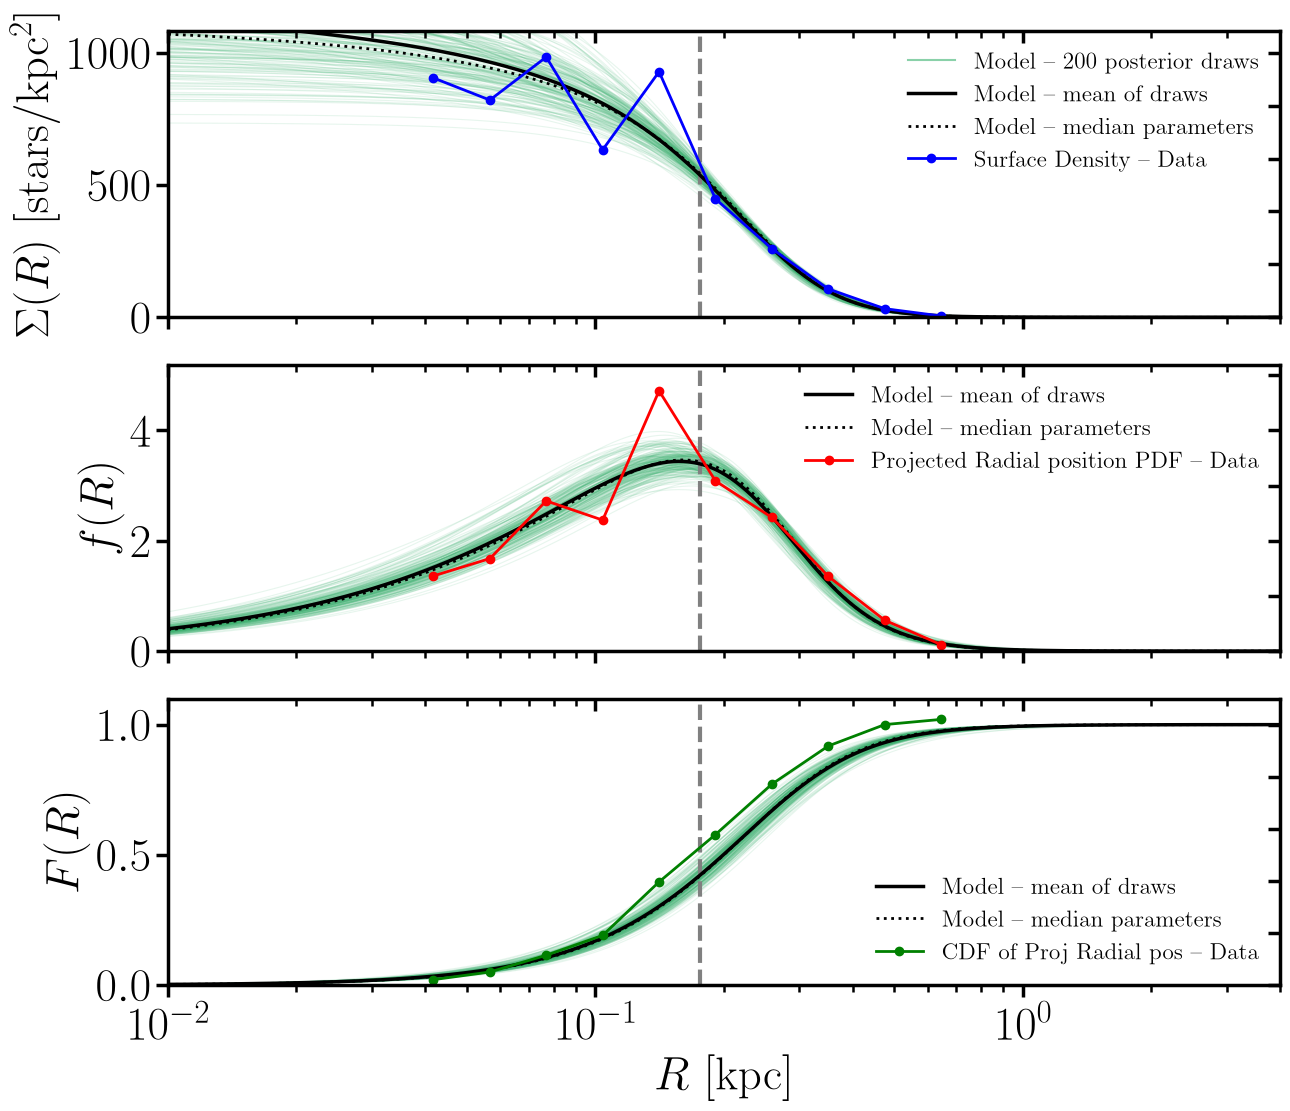

Sigma(R_half) = 536 -24.1 +23.3  [stars/kpc^2]


In [17]:
#--- LeoII: Sigma(R) from posterior draws of the light-profile parameters ---------------------
# Same model as the cell above, but instead of a single curve at the median parameters we
# draw n_draw parameter sets from the posterior and propagate each one through Sigma(R),
# f(R) and F(R).  The thick black line is the mean over the draws (the median-parameter
# curve is kept for reference), the thin lines are the individual draws.

n_draw = 200
rng_draw = np.random.default_rng(42)
idx_draw = rng_draw.choice(len(s1flat), size=min(n_draw, len(s1flat)), replace=False)

Sigma_draws = np.zeros((len(idx_draw), len(r)))
for j, k in enumerate(idx_draw):
    rp_k = 10.0**s1flat[k, i_nu]
    alp_k, bet_k, gam_k = s1flat[k, i_nu+1], s1flat[k, i_nu+2], s1flat[k, i_nu+3]
    # same normalisation convention as the median model: total = N_stars
    rho_k = N_stars / abg_normmass(rp_k, alp_k, bet_k, gam_k)
    Sigma_draws[j, :] = Sigma_abg(r, rho_k, rp_k, alp_k, bet_k, gam_k)

good = np.all(np.isfinite(Sigma_draws), axis=1) & (Sigma_draws > 0).all(axis=1)
Sigma_draws = Sigma_draws[good]
print('%d / %d draws kept' % (good.sum(), len(good)))

f_pos_draws = r*Sigma_draws / np.trapezoid(r*Sigma_draws, r, axis=1)[:, None]
cdf_draws = np.cumsum(f_pos_draws*np.gradient(r), axis=1)

Sigma_mean = Sigma_draws.mean(axis=0)
f_pos_mean = f_pos_draws.mean(axis=0)
cdf_mean = cdf_draws.mean(axis=0)

#--- binned data (recomputed here so the cell stands alone) -----------------------------------
rLOS = star_data[:, 0]

n_bins = 10
r_bins = np.logspace(np.log10(rLOS.min()), np.log10(rLOS.max()), n_bins + 1)
cnt = np.array([np.sum((rLOS >= r_bins[i]) & (rLOS < r_bins[i+1])) for i in range(n_bins)])
keep = cnt > 0                                   # empty bins are dropped, as in the cell above
cen_d = (0.5*(r_bins[:-1] + r_bins[1:]))[keep]
Sig_d = (cnt/(np.pi*(r_bins[1:]**2 - r_bins[:-1]**2)))[keep]
f_pos_d = cen_d*Sig_d / np.trapezoid(cen_d*Sig_d, cen_d)

#--- plot -------------------------------------------------------------------------------------
dl = dict(color=col, lw=0.8, alpha=0.12, zorder=-1)     # thin per-draw lines

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax[0].plot(r, Sigma_draws.T, **dl)
ax[0].plot([], [], color=col, lw=1.5, alpha=0.6,
           label=r'Model -- %d posterior draws' % len(Sigma_draws))
ax[0].plot(r, Sigma_mean, color='k', lw=2.5, label='Model -- mean of draws')
ax[0].plot(r, Sigma_model, color='k', lw=2.0, ls=':', label='Model -- median parameters')
ax[0].plot(cen_d, Sig_d, 'o-', color='blue', lw=2.0, label='Surface Density -- Data')
ax[0].set_ylabel(r'$\Sigma(R)$ [stars/kpc$^2$]', fontsize=fsl)
pretty_ax(ax[0], 0.0, np.max(Sig_d)*1.1)
ax[0].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[1].plot(r, f_pos_draws.T, **dl)
ax[1].plot(r, f_pos_mean, color='k', lw=2.5, label='Model -- mean of draws')
ax[1].plot(r, f_pos_model, color='k', lw=2.0, ls=':', label='Model -- median parameters')
ax[1].plot(cen_d, f_pos_d, 'o-', color='red', lw=2.0, label='Projected Radial position PDF -- Data')
ax[1].set_ylabel(r'$f(R)$', fontsize=fsl)
pretty_ax(ax[1], 0.0, np.max(f_pos_d)*1.1)
ax[1].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[2].plot(r, cdf_draws.T, **dl)
ax[2].plot(r, cdf_mean, color='k', lw=2.5, label='Model -- mean of draws')
ax[2].plot(r, np.cumsum(f_pos_model*np.gradient(r)), color='k', lw=2.0, ls=':',
           label='Model -- median parameters')
ax[2].plot(cen_d, np.cumsum(f_pos_d*np.gradient(cen_d)), 'o-', c='green', lw=2.0,
           label='CDF of Proj Radial pos -- Data')
pretty_ax(ax[2], 0.0, 1.1)
ax[2].set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax[2].set_ylabel(r'$F(R)$', fontsize=fsl)
ax[2].legend(frameon=False, fontsize=fsl*0.5, loc='lower right')

plt.tight_layout()
plt.show()

#--- 68 / 95 per cent envelopes of the drawn Sigma(R), for reference ---------------------------
bS = band(Sigma_draws)
qh = np.percentile(Sigma_draws[:, np.argmin(np.abs(r - Rhalf))], [16, 50, 84])
print('Sigma(R_half) = %.3g -%.3g +%.3g  [stars/kpc^2]' % (qh[1], qh[1]-qh[0], qh[2]-qh[1]))


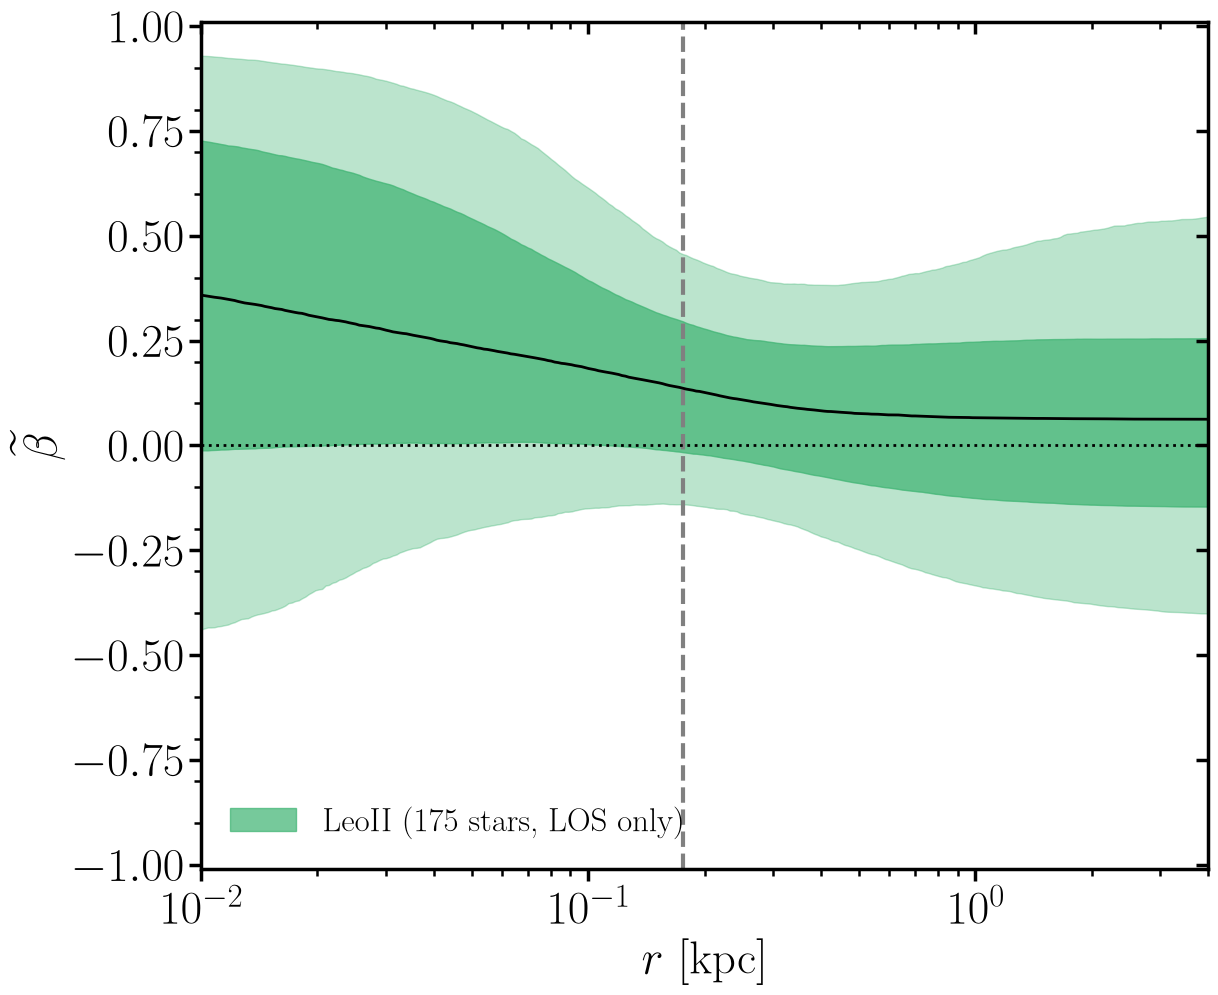

betat(R_half) = 0.14 -0.15 +0.16


In [18]:
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))

## To compare our simulations to observations using gravsphere - we aim to compare distributions of:
## $v_{los}(r)$, $\Sigma (r)$ and $\beta (r)$

In [19]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/gpfs/home/jd925/Adding_stellar_masses")
import jax
jax.config.update("jax_enable_x64", True)
import sys

sys.path.append("/gpfs/home/jd925/Adding_stellar_masses")
import jaxsp as jsp

In [21]:
m22 = 100
r0 = 0.19
Lout = 0.125
rcut = 10

WORKDIR = "/gpfs/home/jd925/Adding_stellar_masses/Checkpoints/LeoII"

m22_str = f"{m22:g}"
r0_str = f"{r0:g}"
Lout_str = f"{Lout:g}"

if rcut is None:
    Ckpt_dir = os.path.join(WORKDIR, f"checkpoints_m22_{m22_str}_r0_{r0_str}_Lout_{Lout_str}")
else:
    Ckpt_dir = os.path.join(WORKDIR, f"checkpoints_rcut{rcut}_m22_{m22_str}_r0_{r0_str}_Lout_{Lout_str}")


u = jsp.set_schroedinger_units(m22)

to_Kpc = float(u.to_Kpc)
to_kms = float(u.to_kms)
to_Gyr = float(u.to_Gyr)

print(f"m22={m22}, r0={r0}, Lout={Lout} (checkpoints: {Ckpt_dir})")

# Load final checkpoint
ckpt_path = os.path.join(Ckpt_dir, "checkpoint_final.pkl")

print(f"\nLoading {ckpt_path}")

with open(ckpt_path, "rb") as f:
    state = pickle.load(f)

n_steps = state["no_time_steps"]
n_ramp  = state.get("n_ramp_steps", 0)
dt_Gyr  = (state["sim_time"] / n_steps) * to_Gyr
#dt_Gyr  = (state["sim_t"] / n_steps) * to_Gyr
print(f"Steps: {n_steps}, ramp steps: {n_ramp}, dt = {dt_Gyr:.5f} Gyr")

particles = state["particle_states"]

r_all  = np.array([p["r_values"] for p in particles])                              # (N_part, N_steps+1)
v_cart = np.array([[np.asarray(v) for v in p["velocities_cart"]] for p in particles])  # (N_part, N_steps+1, 3)
v_sph = np.array([[np.asarray(v) for v in p["velocities"]] for p in particles])      # (N_part, N_steps+1, 3)
r_pos = np.array([p["positions_xyz"] for p in particles])                              # (N_part, N_steps+1, 3)

N_part, N_t = r_all.shape
print(f"Particles: {N_part}, time points: {N_t}")


m22=100, r0=0.19, Lout=0.125 (checkpoints: /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/LeoII/checkpoints_rcut10_m22_100_r0_0.19_Lout_0.125)

Loading /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/LeoII/checkpoints_rcut10_m22_100_r0_0.19_Lout_0.125/checkpoint_final.pkl
Steps: 16100, ramp steps: 0, dt = 0.00062 Gyr
Particles: 1000, time points: 16101


## $v_{los}(r)$

In [22]:
# Pick arbitrary direction to be +ve z in cartesian coordinates

direction = np.array([0.0, 0.0, 1.0])

v_los = np.einsum("ijk,k->ij", v_cart, direction)  # (N_part, N_steps+1)

sim_v_los = v_los[:, -1] * to_kms  # (N_part,)

r_los = np.einsum("ijk,k->ij", r_pos, direction)  # (N_part, N_steps+1)

sim_r_proj = np.linalg.norm(r_pos[:, -1, :] - np.outer(r_los[:, -1], direction), axis=1) * to_Kpc


R_proj range = 0.0355 - 0.7418 kpc   (R_half = 0.1760 kpc)


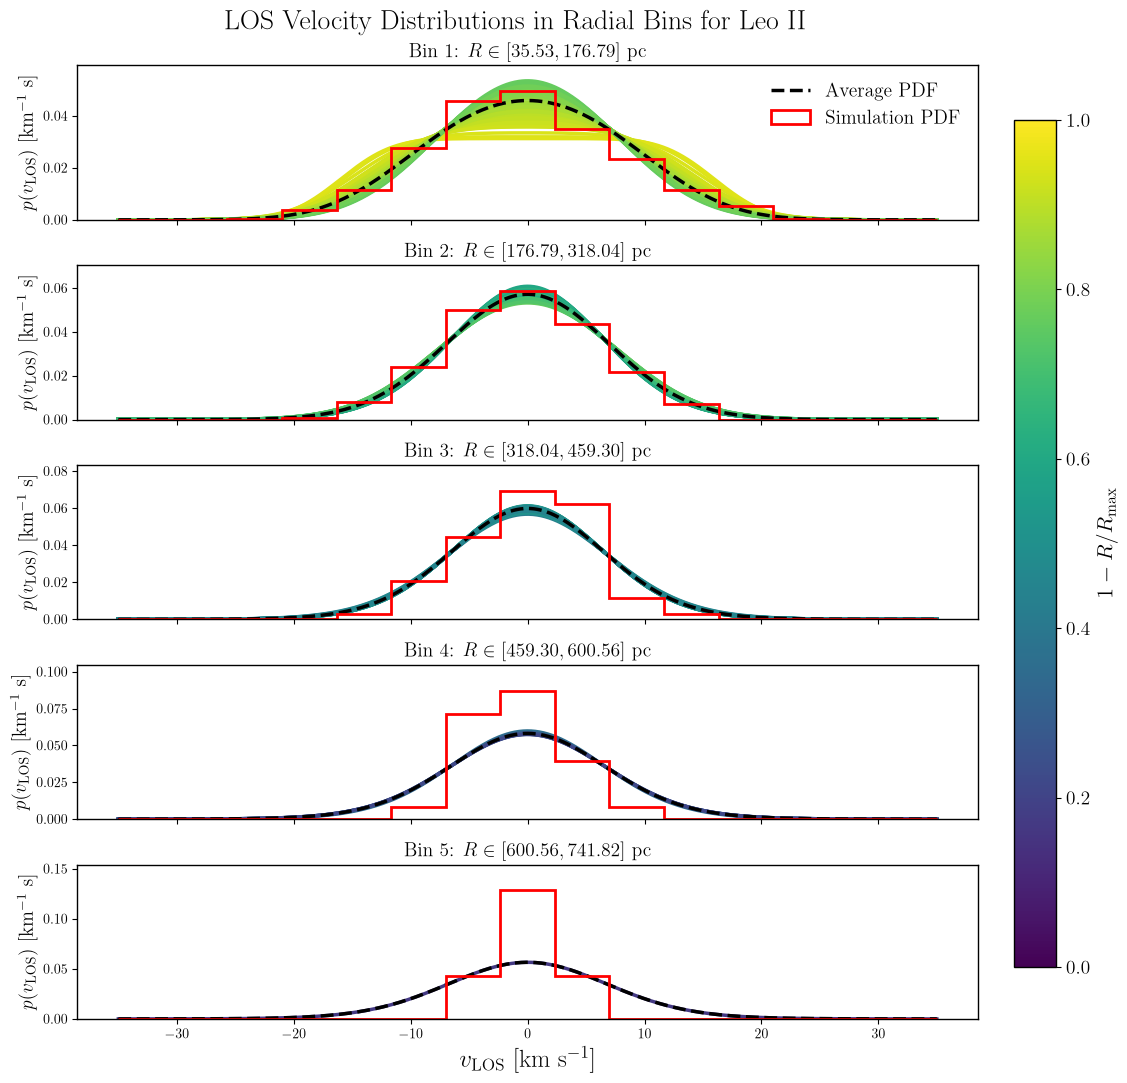

In [23]:

n_bins = 5

rLOS = star_data[:, 0]

print('R_proj range = %.4f - %.4f kpc   (R_half = %.4f kpc)' % (rLOS.min(), rLOS.max(), Rhalf))

bin_edges = np.linspace(rLOS.min(), rLOS.max(), n_bins + 1)

fig, ax = plt.subplots(n_bins, 1, sharex=True, figsize=(13, 11))

for i in range(n_bins):
    mask = (rLOS >= bin_edges[i]) & (rLOS < bin_edges[i + 1])
    bin_rLOS = rLOS[mask]
    bin_vLOS = star_data[mask, 1]
    bin_vLOS_err = star_data[mask, 2]
    sig_at_bin = sig_at[mask]
    kur_at_bin = kur_at[mask]

    sim_mask = (sim_r_proj >= bin_edges[i]) & (sim_r_proj < bin_edges[i + 1])
    sim_bin_v_los = sim_v_los[sim_mask]

    vv = np.linspace(-35.0, 35.0, 1000)

    max_hist = 0.0

    for j, (R, s, k) in enumerate(zip(bin_rLOS, sig_at_bin, kur_at_bin)):
        err = bin_vLOS_err[j]
        ax[i].plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
                   ls='-')


    average_pdf = np.mean([fvel(vv, s, k, err) for s, k, err in zip(sig_at_bin, kur_at_bin, bin_vLOS_err)], axis=0)
    ax[i].plot(vv, average_pdf, color='k', lw=2.5, ls='--', label='Average PDF')

    # for j in range(len(bin_vLOS)):

    #     ax[i].vlines(x = bin_vLOS[j], ymax = average_pdf[np.argmin(abs(vv - bin_vLOS[j]))], ymin = 0, color=plt.cm.viridis(1 - R/R_max), lw=2.5, ls='--', alpha = 0.4)

    y, x, _ = ax[i].hist(sim_bin_v_los, bins=15, range=(-35, 35), density=True, histtype='step', color='red', lw=2, label='Simulation PDF')


    # idx = np.clip(np.searchsorted(x, sim_bin_v_los, side='right') - 1, 0, len(y) - 1)
    # ax[i].vlines(sim_bin_v_los, 0, y[idx], color='red', ls='--', alpha=0.1)



    ax[i].set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=14)
    ax[i].set_title(r'Bin %d: $R \in [%.2f, %.2f]$ pc' % (i + 1, bin_edges[i]*1000, bin_edges[i + 1]*1000), fontsize=14)
    if i == 0:
        ax[i].legend(frameon=False, fontsize=14)

    max_hist = np.max(y)
    ax[i].set_ylim(0, max_hist * 1.2)


ax[-1].set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=18)
fig.suptitle('LOS Velocity Distributions in Radial Bins for Leo II', fontsize=20, x=0.4)
cbar = fig.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', pad = -0.45)

cbar.ax.tick_params(labelsize=14) 
cbar.set_label(r'$1 - R/R_{\max}$', size=16)

plt.tight_layout()
plt.show()


## $\Sigma(R)$

In [24]:
n_bins = 10
r_bins = np.logspace(np.log10(rLOS.min()), np.log10(rLOS.max()), n_bins + 1)

masks = np.array([np.sum((sim_r_proj >= r_bins[i]) & (sim_r_proj < r_bins[i+1])) for i in range(n_bins)])

keep = masks > 0                                  
sim_cen_d = (0.5*(r_bins[:-1] + r_bins[1:]))[keep]
sim_Sig_d = (masks/(np.pi*(r_bins[1:]**2 - r_bins[:-1]**2)))[keep] * (N_stars / N_part)
sim_f_pos_d = sim_cen_d*sim_Sig_d / np.trapezoid(sim_cen_d*sim_Sig_d, sim_cen_d)

print(sim_Sig_d)

[ 949.88290162 1580.5652008  1017.2208288   877.791303    668.29575464
  444.80641217  253.23769724  107.92577751   26.52944789    3.33394381]


200 / 200 draws kept


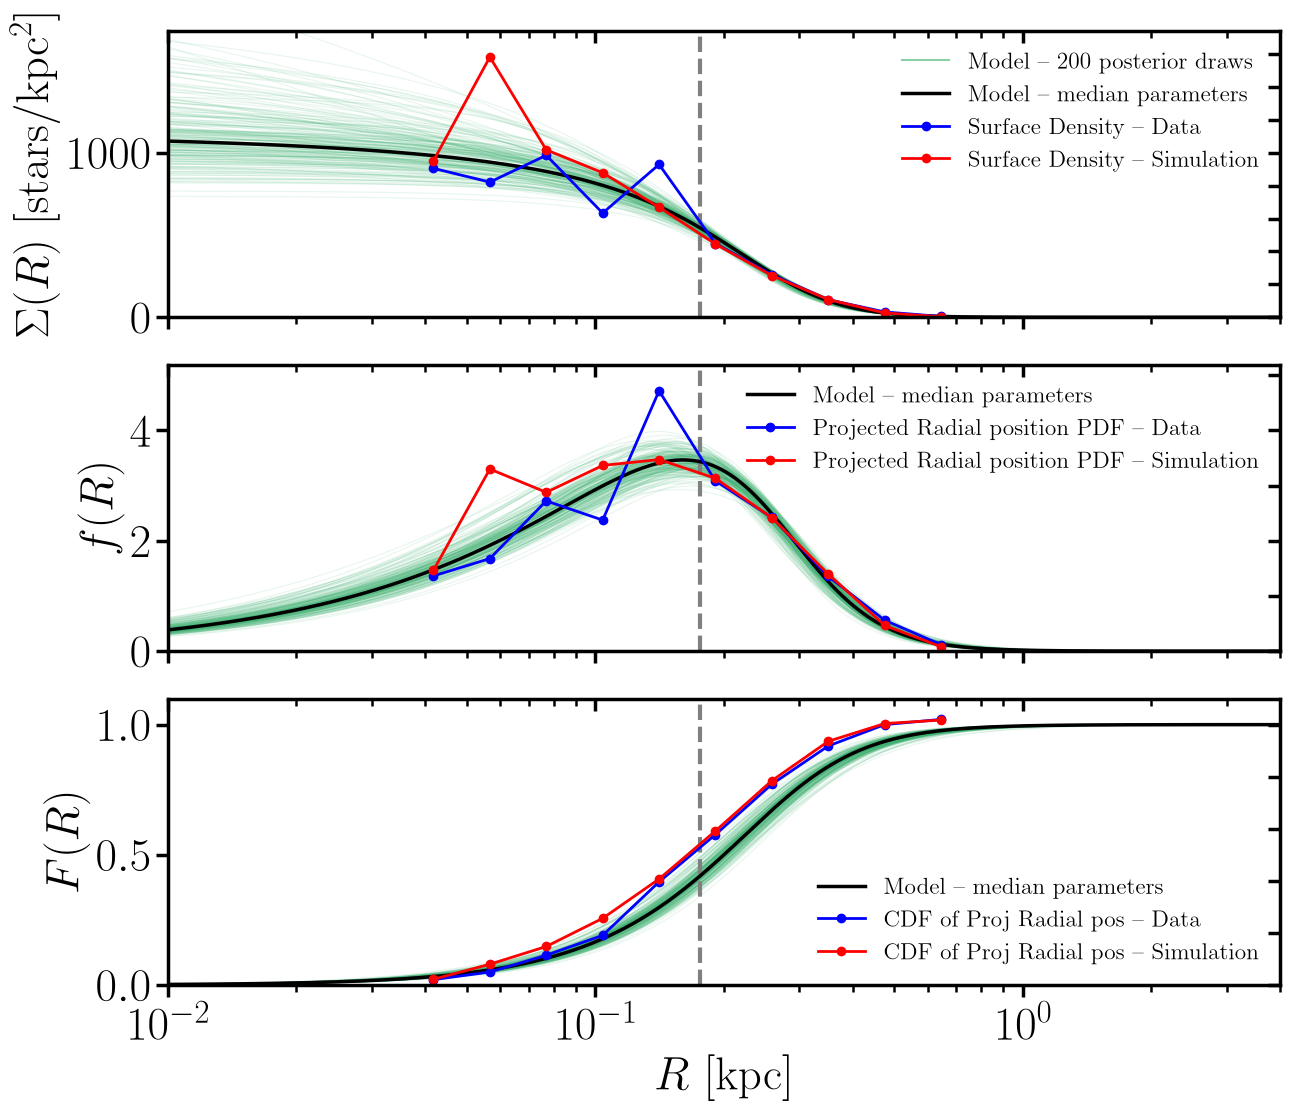

Sigma(R_half) = 536 -24.1 +23.3  [stars/kpc^2]


In [25]:

n_draw = 200
rng_draw = np.random.default_rng(42)
idx_draw = rng_draw.choice(len(s1flat), size=min(n_draw, len(s1flat)), replace=False)

Sigma_draws = np.zeros((len(idx_draw), len(r)))
for j, k in enumerate(idx_draw):
    rp_k = 10.0**s1flat[k, i_nu]
    alp_k, bet_k, gam_k = s1flat[k, i_nu+1], s1flat[k, i_nu+2], s1flat[k, i_nu+3]
    # same normalisation convention as the median model: total = N_stars
    rho_k = N_stars / abg_normmass(rp_k, alp_k, bet_k, gam_k)
    Sigma_draws[j, :] = Sigma_abg(r, rho_k, rp_k, alp_k, bet_k, gam_k)

good = np.all(np.isfinite(Sigma_draws), axis=1) & (Sigma_draws > 0).all(axis=1)
Sigma_draws = Sigma_draws[good]
print('%d / %d draws kept' % (good.sum(), len(good)))

f_pos_draws = r*Sigma_draws / np.trapezoid(r*Sigma_draws, r, axis=1)[:, None]
cdf_draws = np.cumsum(f_pos_draws*np.gradient(r), axis=1)


#--- binned data (recomputed here so the cell stands alone) -----------------------------------
rLOS = star_data[:, 0]


cnt = np.array([np.sum((rLOS >= r_bins[i]) & (rLOS < r_bins[i+1])) for i in range(n_bins)])
keep = cnt > 0                                   # empty bins are dropped, as in the cell above
cen_d = (0.5*(r_bins[:-1] + r_bins[1:]))[keep]
Sig_d = (cnt/(np.pi*(r_bins[1:]**2 - r_bins[:-1]**2)))[keep]
f_pos_d = cen_d*Sig_d / np.trapezoid(cen_d*Sig_d, cen_d)


#--- plot -------------------------------------------------------------------------------------
dl = dict(color=col, lw=0.8, alpha=0.12, zorder=-1)     # thin per-draw lines

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax[0].plot(r, Sigma_draws.T, **dl)
ax[0].plot([], [], color=col, lw=1.5, alpha=0.6,
           label=r'Model -- %d posterior draws' % len(Sigma_draws))
ax[0].plot(r, Sigma_model, color='k', lw=2.5, label='Model -- median parameters')
ax[0].plot(cen_d, Sig_d, 'o-', color='blue', lw=2.0, label='Surface Density -- Data')
ax[0].plot(sim_cen_d, sim_Sig_d, 'o-', color='red', lw=2.0, label='Surface Density -- Simulation')
ax[0].set_ylabel(r'$\Sigma(R)$ [stars/kpc$^2$]', fontsize=fsl)
pretty_ax(ax[0], 0.0, max(np.max(Sig_d*1.1), np.max(sim_Sig_d*1.1)))
ax[0].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[1].plot(r, f_pos_draws.T, **dl)
ax[1].plot(r, f_pos_model, color='k', lw=2.5, label='Model -- median parameters')
ax[1].plot(cen_d, f_pos_d, 'o-', color='blue', lw=2.0, label='Projected Radial position PDF -- Data')
ax[1].plot(sim_cen_d, sim_f_pos_d, 'o-', color='red', lw=2.0, label='Projected Radial position PDF -- Simulation')
ax[1].set_ylabel(r'$f(R)$', fontsize=fsl)
pretty_ax(ax[1], 0.0, max(np.max(f_pos_d*1.1), np.max(sim_f_pos_d*1.1)))
ax[1].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[2].plot(r, cdf_draws.T, **dl)
ax[2].plot(r, np.cumsum(f_pos_model*np.gradient(r)), color='k', lw=2.5, label='Model -- median parameters')
ax[2].plot(cen_d, np.cumsum(f_pos_d*np.gradient(cen_d)), 'o-', c='blue', lw=2.0,
           label='CDF of Proj Radial pos -- Data')
ax[2].plot(sim_cen_d, np.cumsum(sim_f_pos_d*np.gradient(sim_cen_d)), 'o-', c='red', lw=2.0,
           label='CDF of Proj Radial pos -- Simulation')
pretty_ax(ax[2], 0.0, 1.1)
ax[2].set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax[2].set_ylabel(r'$F(R)$', fontsize=fsl)
ax[2].legend(frameon=False, fontsize=fsl*0.5, loc='lower right')

plt.tight_layout()
plt.show()

#--- 68 / 95 per cent envelopes of the drawn Sigma(R), for reference ---------------------------
bS = band(Sigma_draws)
qh = np.percentile(Sigma_draws[:, np.argmin(np.abs(r - Rhalf))], [16, 50, 84])
print('Sigma(R_half) = %.3g -%.3g +%.3g  [stars/kpc^2]' % (qh[1], qh[1]-qh[0], qh[2]-qh[1]))


## $\beta(r)$

In [26]:
# Simulation Beta

beta_sim_plot = []

n_bins = 8

for i in range(2):

    if i == 0:
        time = 0
    else:
        time = -1

    r_bins = np.logspace(np.log10(r_all[:, time].min()), np.log10(r_all[:, time].max()), n_bins + 1)

    bin_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

    masks = [(r_all[:, time] >= r_bins[i]) & (r_all[:, time] < r_bins[i+1]) for i in range(n_bins)]

    sigma_t = np.zeros(n_bins)
    sigma_r = np.zeros(n_bins)


    def Cartesian_to_sph_vel_np(x, y, z, vx, vy, vz):
        r = np.sqrt(x*x + y*y + z*z)
        rho_xy = np.sqrt(x*x + y*y)
        vr = (x*vx + y*vy + z*vz) / r
        vtheta = (z*(x*vx + y*vy) - (x**2 + y**2) * vz) / (r * rho_xy)
        vphi = (x*vy - y*vx) / rho_xy
        return vr, vtheta, vphi

    vr, vtheta, vphi = Cartesian_to_sph_vel_np(r_pos[:, time, 0], r_pos[:, time, 1], r_pos[:, time, 2],
                                            v_cart[:, time, 0], v_cart[:, time, 1], v_cart[:, time, 2])


    for i in range(n_bins):
        mask = masks[i]
        if np.sum(mask) > 20:
            sigma_theta = np.sqrt(np.mean(vtheta[mask]**2) - np.mean(vtheta[mask])**2) * to_kms
            sigma_phi = np.sqrt(np.mean(vphi[mask]**2) - np.mean(vphi[mask])**2) * to_kms
            sigma_t[i] = np.sqrt(sigma_theta**2 + sigma_phi**2)
            sigma_r[i] = np.sqrt(np.mean(vr[mask]**2) - np.mean(vr[mask])**2) * to_kms
        else:
            sigma_t[i] = np.nan
            sigma_r[i] = np.nan


    beta_sim = 1 - (sigma_t**2) / (2 * sigma_r**2)

    bin_centers = bin_centers[~np.isnan(beta_sim)]
    beta_sim = beta_sim[~np.isnan(beta_sim)]

    beta_sim = beta_sim / (2 - beta_sim)

    beta_sim_plot.append((bin_centers, beta_sim))




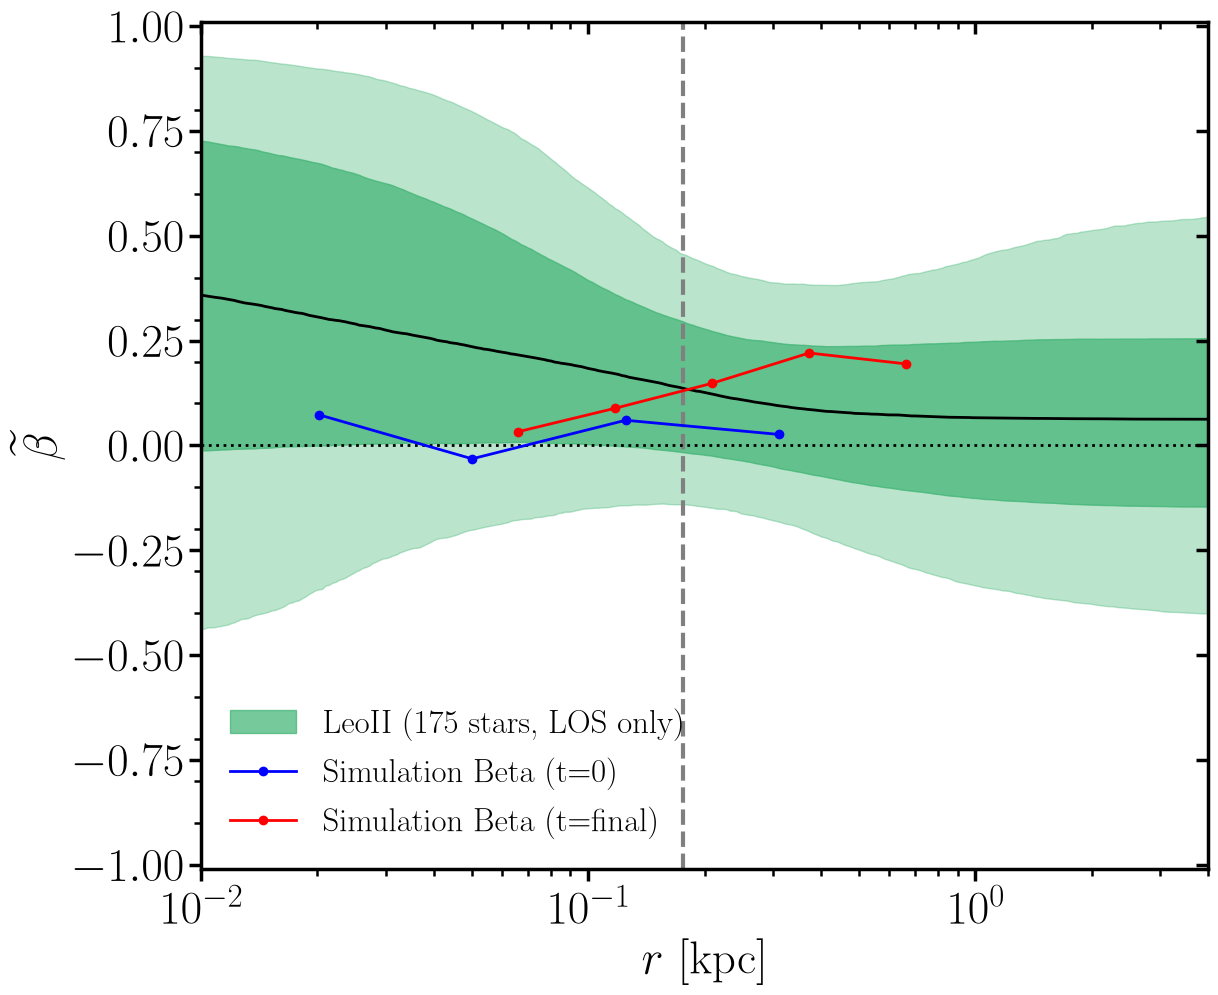

betat(R_half) = 0.14 -0.15 +0.16


In [27]:
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic

for i in range(2):
    bin_centers, beta_sim = beta_sim_plot[i]
    l = 'Simulation Beta (t=0)' if i == 0 else 'Simulation Beta (t=final)'
    color = 'blue' if i == 0 else 'red'
    ax.plot(bin_centers * to_Kpc, beta_sim, 'o-', color=color, lw=2.0, label=l)

ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))

In [41]:
# Get simulation beta'

n_bins = 8

beta_prime_sim_plot = np.zeros((2, n_bins))

for i in range(2):

    if i == 0:
        time = 0
    else:
        time = -1

    r_bins = np.logspace(np.log10(r_all[:, time].min()), np.log10(r_all[:, time].max()), n_bins + 1)

    bin_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

    masks = [(r_all[:, time] >= r_bins[i]) & (r_all[:, time] < r_bins[i+1]) for i in range(n_bins)]


    def Cartesian_to_sph_vel_np(x, y, z, vx, vy, vz):
        r = np.sqrt(x*x + y*y + z*z)
        rho_xy = np.sqrt(x*x + y*y)
        vr = (x*vx + y*vy + z*vz) / r
        vtheta = (z*(x*vx + y*vy) - (x**2 + y**2) * vz) / (r * rho_xy)
        vphi = (x*vy - y*vx) / rho_xy
        return vr, vtheta, vphi

    vr, vtheta, vphi = Cartesian_to_sph_vel_np(r_pos[:, time, 0], r_pos[:, time, 1], r_pos[:, time, 2],
                                            v_cart[:, time, 0], v_cart[:, time, 1], v_cart[:, time, 2])


    for j in range(n_bins):
        mask = masks[j]
        total_in_bin = np.sum(mask)
        if np.sum(mask) > 20:

            v_r_2 = np.sum(vr[mask]**2)/total_in_bin
            v_t_2 = np.sum(vtheta[mask]**2 + vphi[mask]**2)/total_in_bin
            v_r_4 = np.sum(vr[mask]**4)/total_in_bin
            v_r_t_2 = np.sum(vr[mask]**2 * (vtheta[mask]**2 + vphi[mask]**2))/total_in_bin
            
            beta_primed_in_bin = 1 - 3/2 * (v_r_t_2) / (v_r_4)
        
        else:
            beta_primed_in_bin = np.nan

        beta_prime_sim_plot[i, j] = beta_primed_in_bin

    



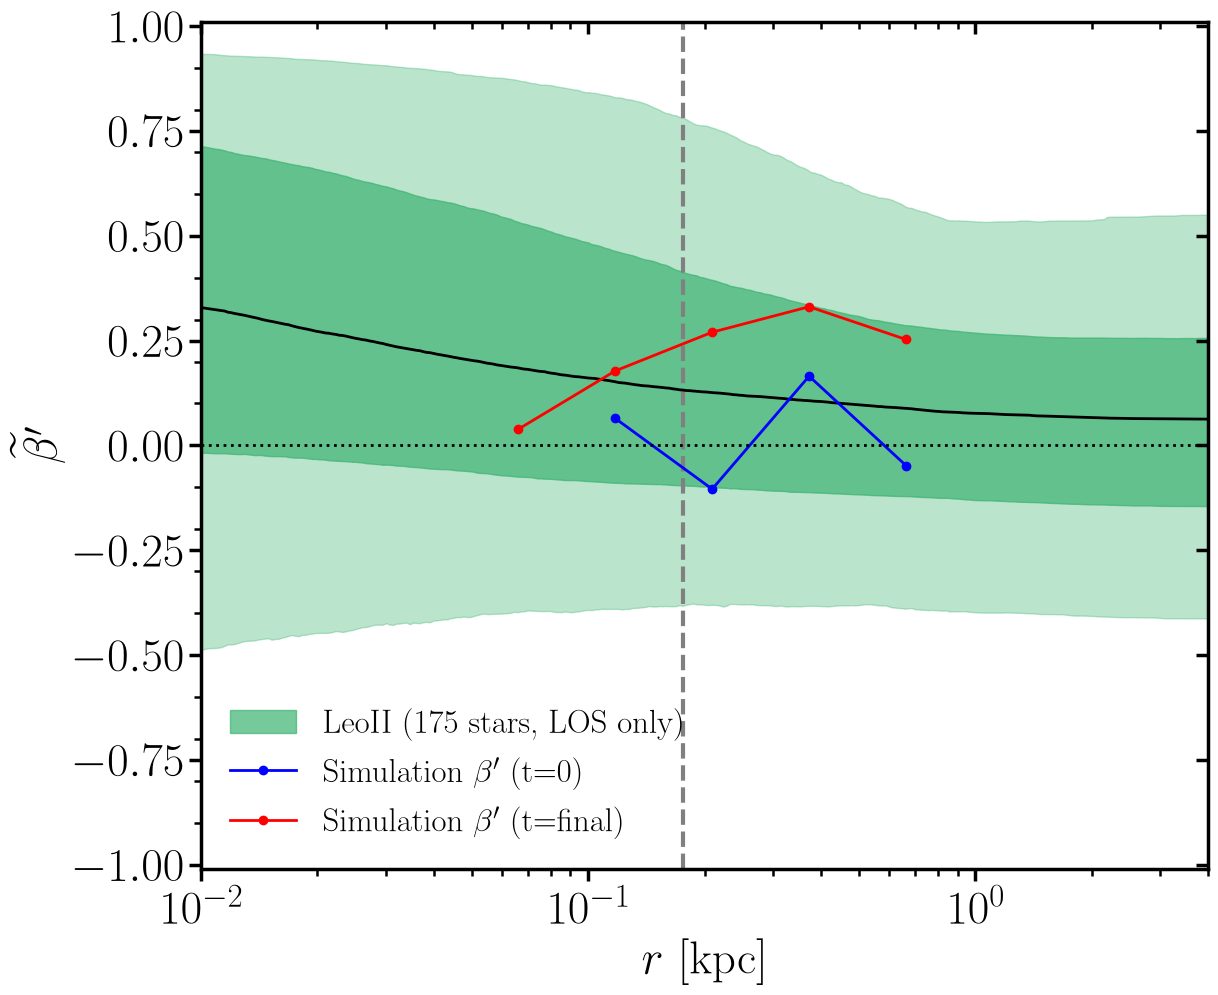

betat(R_half) = 0.13 -0.23 +0.28


In [48]:

# symmetrised anisotropy  betat = beta / (2 - beta)
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[4] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[5] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[4:8])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)


for i in range(2):
    beta_sim = beta_prime_sim_plot[i, :]
    l = r"Simulation $\beta'$ (t=0)" if i == 0 else r"Simulation $\beta'$ (t=final)"
    color = 'blue' if i == 0 else 'red'
    ax.plot(bin_centers * to_Kpc, beta_sim, 'o-', color=color, lw=2.0, label=l)


ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r"$\widetilde{\beta'}$", fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')

plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))


## cNFWt (coreNFWtides) parameter posteriors

The DM halo block of $\Theta$ is columns `i_dm = 2*n_betpars + nu_components` to `i_dm+5`:
$\log M_{200}$, $c_{200}$, $\log r_c$, $n$, $\log r_t$, $\delta$.

Three views below: (1) the $6\times6$ corner of just those columns, drawn on the **prior box** so a
marginal that fills its panel is prior-limited; (2) the 1D marginals with the flat prior overlaid and
the KL divergence posterior-vs-prior, which says how many nats the 25 stars actually bought;
(3) the derived halo quantities ($r_{200}$, $r_s$, $r_c/R_{1/2}$, $r_t/R_{\rm max}$, $M(<R_{1/2})$),
which are what the data constrain even when the sampled parameters are not.

Read these with the warning in `initialise_Seg2.py` in mind: Segue 2's dispersion is an upper limit,
so a tight-looking $M_{200}$ is a prior statement unless the KL number says otherwise.

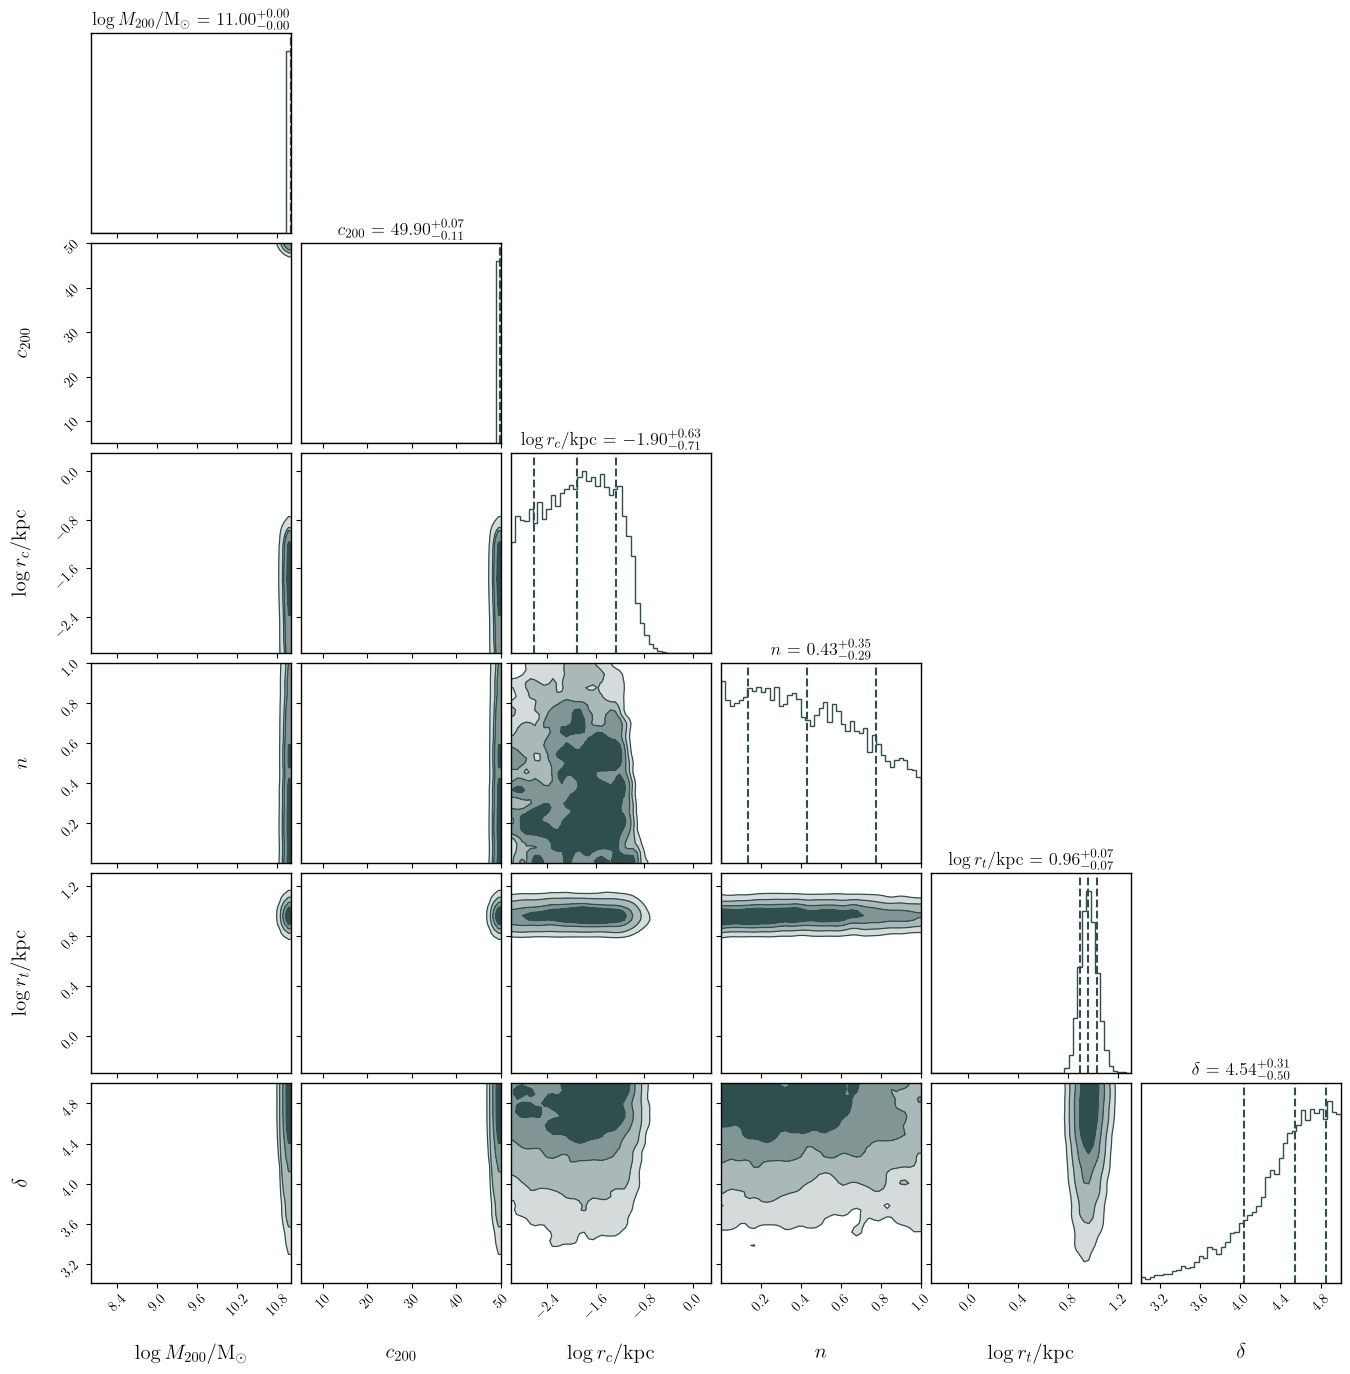

param                16%       50%       84%   prior              f_low  f_high
logM200           10.997    10.999    11.000   [  8.00,  11.00]    0.00    1.00  <- piled on upper edge
c200              49.785    49.899    49.972   [  5.00,  50.00]    0.00    1.00  <- piled on upper edge
log rc            -2.611    -1.900    -1.267   [ -3.00,   0.30]    0.13    0.00
n                  0.137     0.430     0.776   [  0.00,   1.00]    0.12    0.07
log rt             0.896     0.962     1.031   [ -0.30,   1.30]    0.00    0.01
delta              4.040     4.544     4.857   [  3.01,   5.00]    0.01    0.22

f_low/f_high = posterior fraction inside the outer 10% of the prior range
(a flat prior gives 0.10 each; >~0.3 means the edge, not the data, is setting the limit)


In [17]:
#--- cNFWt only: 6x6 corner on the prior box --------------------------------------------------
import corner

i_dm   = 2*n_betpars + nu_components          # first coreNFWtides column (12 for ndims = 18)
dm_idx = np.arange(i_dm, i_dm + 6)
dm_labs = [r'$\log M_{200}$/M$_{\odot}$', r'$c_{200}$', r'$\log r_c$/kpc',
           r'$n$', r'$\log r_t$/kpc', r'$\delta$']
dm_samp = s1flat[:, dm_idx]
dm_rng  = [(minarr[i], maxarr[i]) for i in dm_idx]

levs_dm = (1 - np.exp(-(1.0)**2/2), 1 - np.exp(-(1.5)**2/2),
           1 - np.exp(-(2.0)**2/2), 1 - np.exp(-(2.5)**2/2))

fig = corner.corner(dm_samp, labels=dm_labs, range=dm_rng,
                    quantiles=(0.16, 0.5, 0.84), show_titles=True, title_fmt='.2f',
                    label_kwargs=dict(fontsize=15), title_kwargs=dict(fontsize=13),
                    bins=45, smooth=1.1, fill_contours=True, color='darkslategray',
                    plot_datapoints=False, plot_density=False,
                    contour_kwargs={'linewidths': 0.9}, levels=levs_dm, use_math_text=True)

plt.savefig(str(diro + 'Plots/corner_cnfwt_Segue2.pdf'), bbox_inches='tight')
plt.show()

#--- how much of each marginal is jammed against its prior edge? ------------------------------
print('%-14s %9s %9s %9s   %-16s %7s %7s' %
      ('param', '16%', '50%', '84%', 'prior', 'f_low', 'f_high'))
for j, i in enumerate(dm_idx):
    lo, hi = minarr[i], maxarr[i]
    q = np.percentile(s1flat[:, i], [16, 50, 84])
    edge = 0.1*(hi - lo)                                   # outer 10% of the prior range
    f_lo = np.mean(s1flat[:, i] < lo + edge)
    f_hi = np.mean(s1flat[:, i] > hi - edge)
    flag = ''
    if f_lo > 0.3: flag = '  <- piled on lower edge'
    if f_hi > 0.3: flag = '  <- piled on upper edge'
    print('%-14s %9.3f %9.3f %9.3f   [%6.2f, %6.2f] %7.2f %7.2f%s'
          % (['logM200', 'c200', 'log rc', 'n', 'log rt', 'delta'][j],
             q[0], q[1], q[2], lo, hi, f_lo, f_hi, flag))
print('\nf_low/f_high = posterior fraction inside the outer 10% of the prior range')
print('(a flat prior gives 0.10 each; >~0.3 means the edge, not the data, is setting the limit)')

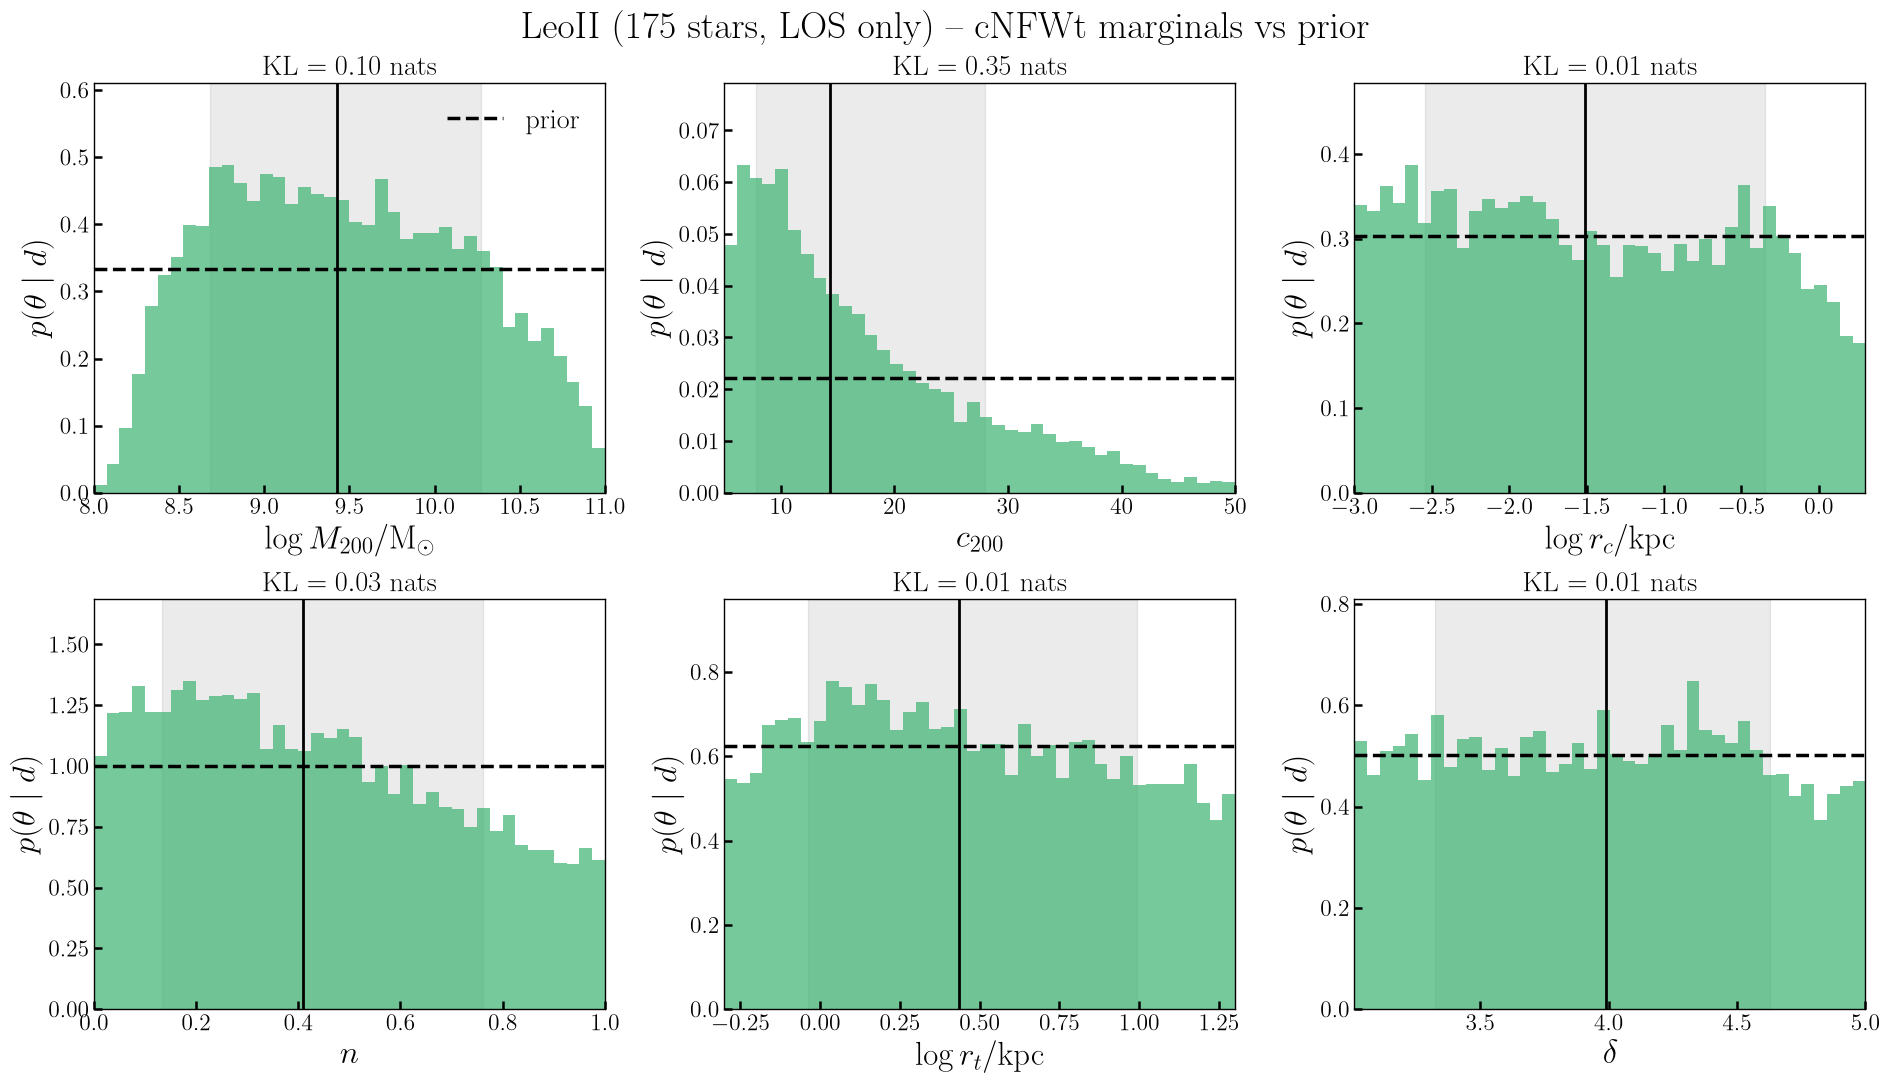

In [9]:
#--- cNFWt: 1D marginals against the flat prior, with the information gain ---------------------
# KL(posterior || prior) in nats, computed on the same histogram that is drawn. 0 nats = the
# marginal IS the prior (the 25 Segue 2 velocities said nothing about that parameter);
# ~1 nat = the posterior occupies roughly 1/e of the prior range.

nbins_m = 40
fig, axs = plt.subplots(2, 3, figsize=(19, 11))

for ax, i, lab in zip(axs.ravel(), dm_idx, dm_labs):
    lo, hi = minarr[i], maxarr[i]
    p, edges = np.histogram(s1flat[:, i], bins=nbins_m, range=(lo, hi), density=True)
    cen = 0.5*(edges[:-1] + edges[1:])
    dx = edges[1] - edges[0]
    prior = 1.0/(hi - lo)
    kl = np.sum(np.where(p > 0, p*np.log(np.where(p > 0, p, 1.0)/prior), 0.0))*dx

    q = np.percentile(s1flat[:, i], [16, 50, 84])
    ax.bar(cen, p, width=dx, color=col, alpha=al, edgecolor='none')
    ax.axhline(prior, ls='--', lw=2.5, color='k', label='prior')
    ax.axvspan(q[0], q[2], color='k', alpha=0.08, zorder=0)
    ax.axvline(q[1], color='k', lw=2.0, zorder=3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(0.0, max(p.max(), prior)*1.25)
    ax.set_xlabel(lab, fontsize=fsl*0.7)
    ax.set_ylabel(r'$p(\theta \mid d)$', fontsize=fsl*0.7)
    ax.set_title(r'KL $= %.2f$ nats' % kl, fontsize=fsl*0.6)
    ax.tick_params(labelsize=fst*0.5)
    ax.tick_params('both', length=6, width=1.8, which='major', direction='in')

axs.ravel()[0].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')
fig.suptitle(leg + r' -- cNFWt marginals vs prior', fontsize=fsl*0.8)
plt.tight_layout()
plt.savefig(str(diro + 'Plots/marginals_cnfwt_Segue2.pdf'), bbox_inches='tight')
plt.show()

In [10]:
import jax.numpy as jnp
import jax
import sys
sys.path.append('/gpfs/home/jd925/Adding_stellar_masses/simple_sim')
import Sharding_manager as sm

sys.path.append('/gpfs/home/jd925/Adding_stellar_masses')
import jaxsp as jsp


m22 = 1000
u = jsp.set_schroedinger_units(m22)
no_radius_bins = 1000
R_bin = no_radius_bins
r_min = 0.05
r_max_enclosing_frac = 0.99

gal_name = "SegII"

KeyboardInterrupt: 

In [ ]:
# Sample the posteriors 

n_draw = 1
rng_draw = np.random.default_rng(42)
idx_draw = rng_draw.choice(len(s1flat), size=min(n_draw, len(s1flat)), replace=False)

param_draws = np.zeros((len(idx_draw), len(dm_idx)))
for j, k in enumerate(idx_draw):
    for l, i in enumerate(dm_idx):
        param_draw = s1flat[k, i]

        param_draws[j, l] = param_draw

for draw in param_draws:

    cNFWtides_params = jnp.array([
    10**draw[0] * u.from_Msun,
    draw[1],
    draw[3],
    10**(draw[2]) * u.from_Kpc,
    10**(draw[4]) * u.from_Kpc,
    draw[5]
    ])

    u = jsp.set_schroedinger_units(m22)

    print("Initializing density parameters...")

    density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

    N = 512
    rmin = 0.01 * u.from_pc
    rmax = jsp.enclosing_radius(0.999, density_params)

    print("Initializing potential parameters...")
    potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)



    eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

    N = 1024
    a = 1
    b = 10

    rmax = jsp.enclosing_radius(r_max_enclosing_frac, density_params)

    print("Initializing eigenstate library...")
    cpu = jax.devices('cpu')[0]
    with jax.default_device(cpu):
        eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)
    print(f"  eigenstate_lib.J={eigenstate_lib.J}, J % {len(jax.devices())} devices = {eigenstate_lib.J % len(jax.devices())}")

    rmin = r_min * u.from_pc

    tol = 1e-7
    print("Initializing wavefunction parameters...")
    wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol, sharding_manager=sm)


    print("Creating wavefunctions...")
    r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), R_bin)

    Nj = eigenstate_lib.J
    chunk = 256
    R_j_r_chunks = []
    for i in range(0, Nj, chunk):
        chunk_result = eval_library(r, jax.tree.map(lambda x: x[i:i+chunk], eigenstate_lib.radial_eigenmode_params))
        R_j_r_chunks.append(np.array(chunk_result))

    R_j_r = np.concatenate(R_j_r_chunks, axis=1)

    l          = np.array(eigenstate_lib.radial_eigenmode_params.l)
    E          = np.array(eigenstate_lib.radial_eigenmode_params.E)
    aj_2       = np.array(wavefunction_params.aj_2)
    total_mass = float(wavefunction_params.total_mass)


    rho_r = ((2 * l + 1)/ (4*np.pi) * abs(R_j_r)**2 * total_mass) @ aj_2

    plt.plot(r, rho_r, label = r'$\psi\psi^*$')

    rho_cnfwt = jsp.core_nfw_tides_rho(r, density_params)

    plt.plot(r, rho_cnfwt, label = 'cNFWt from params')


plt.xscale('log')
plt.yscale('log')
plt.xlabel('R[Kpc]')
plt.ylabel(r'$\rho(r)$')
plt.legend()

plt.show()

Initializing density parameters...
Initializing potential parameters...
Initializing eigenstate library...
  eigenstate_lib.J=3677699, J % 1 devices = 0
Initializing wavefunction parameters...


### Posterior on the velocity dispersion

The cNFWt parameters are unconstrained because $\sigma_{\rm LOS}$ itself is not detected: the
scatter of the 25 velocities is fully accounted for by their errors. The cell below plots that
directly -- the data-only posterior on a single constant $\sigma$ (Kirby+13-style, no Jeans model
involved) next to GravSphere's own $\sigma_{\rm LOS}(R_{1/2})$ from the 18-parameter chain.
A posterior that peaks at $\sigma = 0$ and merely falls off is an upper limit, and every mass
derived from it is an upper limit too.

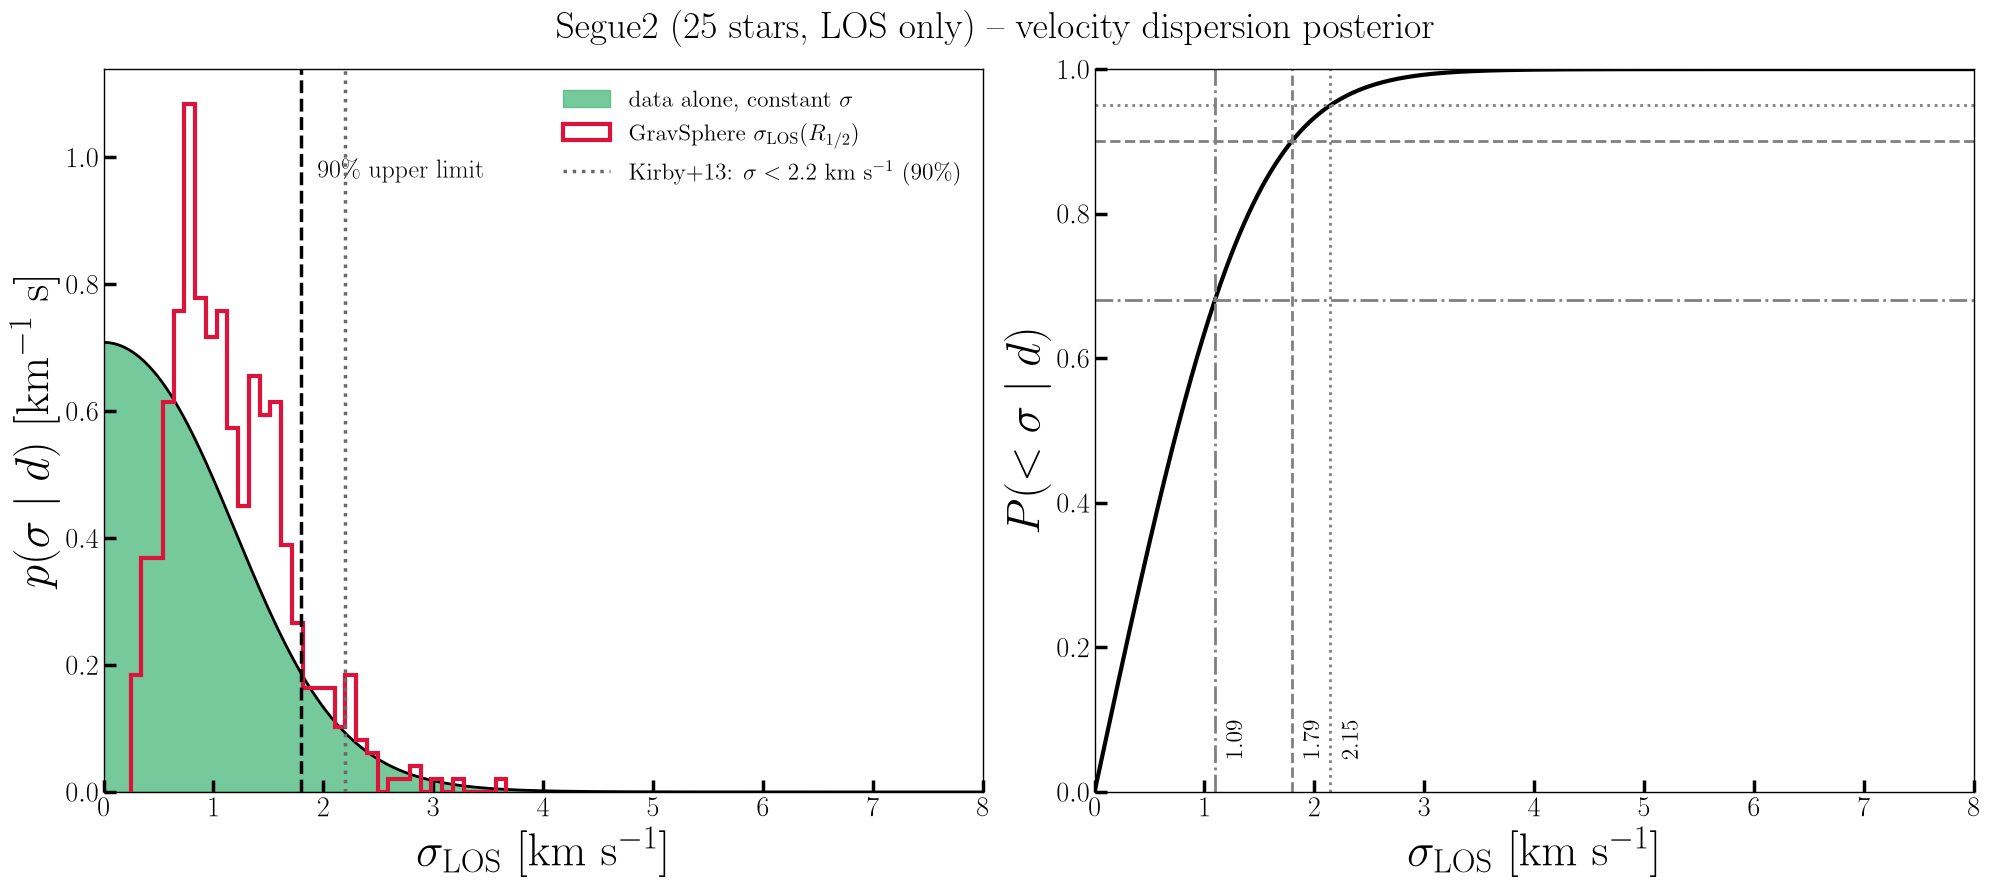

data alone (constant sigma, v_sys marginalised, flat prior in sigma):
   median            = 0.75 km/s
   68% upper limit   = 1.09 km/s
   90% upper limit   = 1.79 km/s   (Kirby+13: 2.2)
   95% upper limit   = 2.15 km/s   (Kirby+13: 2.6)
   p(sigma=0)/p(peak) = 1.00  <- ~1 means the errors explain the whole scatter

GravSphere sigma_LOS(R_half) = 1.06 -0.40 +0.58 km/s
rms velocity scatter = 2.53 km/s vs rms error = 7.59 km/s


In [ ]:
#--- Segue2: posterior on the LOS velocity dispersion -----------------------------------------
# Two posteriors, both in km/s, on the same axis:
#
#   (a) data alone -- ONE constant sigma for all 25 stars, Gaussian likelihood with the per-star
#       errors, systemic velocity marginalised over a grid, flat prior in sigma on [0, 20].
#       No Jeans model, no halo: this is what the velocities alone say.
#   (b) GravSphere -- sigma_LOS(R_half) drawn from the full 18-parameter posterior, i.e. the
#       dispersion the fitted cNFWt halo + anisotropy actually produce at the half-light radius.
#
# (b) sitting on top of (a) means the Jeans machinery is not inventing signal. (a) peaking at
# sigma = 0 means there is no signal to fit.

#--- (a) data-only posterior -------------------------------------------------------------------
sig_grid = np.linspace(0.0, 20.0, 1500)                      # km/s
mu_grid  = np.linspace(vLOS.min() - 10.0, vLOS.max() + 10.0, 400)

var  = sig_grid[:, None, None]**2 + vLOS_err[None, None, :]**2
lnL  = -0.5*np.sum((vLOS[None, None, :] - mu_grid[None, :, None])**2/var
                   + np.log(2.0*np.pi*var), axis=2)
p_sig = np.exp(lnL - lnL.max()).sum(axis=1)                  # marginalise v_sys
p_sig /= np.trapezoid(p_sig, sig_grid)
cdf_sig = intc(p_sig, sig_grid, initial=0.0)                 # cumulative_trapezoid
lim = np.interp([0.5, 0.68, 0.90, 0.95], cdf_sig, sig_grid)

#--- (b) GravSphere sigma_LOS(R_half) ----------------------------------------------------------
# Re-uses upacsl from the sigma_LOS / kappa_LOS cell if it is still in the kernel; otherwise
# recomputes n_sig draws the same way (~0.14 s each).
n_sig = 300
if 'upacsl' in globals() and np.shape(upacsl)[1] == len(Ra):
    sl_draws = upacsl
else:
    sl_draws = np.zeros((n_sig, len(Ra)))
    for it in range(n_sig):
        theta = np.copy(s1flat[np.random.randint(len(s1flat))])
        for j in (0, 1, 4, 5):
            theta[j] = 2.0*theta[j]/(1 + theta[j])           # symmetrised -> ordinary beta
        for i in logthis:
            theta[i] = 10**theta[i]
        surc = theta[2*n_betpars:2*n_betpars+nu_components]
        if individual == True:
            surc = np.append(np.array([1.0]), surc)
        rhobs = alpbetgamden(nu_rad, *surc)
        sobs  = alpbetgamsurf(nu_rad, *surc, bar_pnts)
        baranr  = lambda r: np.interp(r, nu_rad, rhobs, right=1e-30)
        barsurf = lambda r: np.interp(r, nu_rad, sobs,  right=1e-30)
        Mpars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]
        Mfun = lambda r, Mparsu: corenfw_tides_mass(r, *Mparsu)
        _, los2, _, _ = sigp_k(np.array([1.0]), Ra, baranr, barsurf, Mfun, beta, betaf,
                               Mpars, theta[:4], theta[4:8], rmin, rmax, nonn=rcn)
        sl_draws[it, :] = los2**0.5/1e3
    print('computed %d sigma_LOS draws' % n_sig)

sig_gs = np.array([np.interp(Rhalf, Ra, row) for row in sl_draws])
q_gs = np.percentile(sig_gs, [16, 50, 84])

#--- plot --------------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(20, 9))

ax[0].fill_between(sig_grid, 0, p_sig, color=col, alpha=al, zorder=1,
                   label=r'data alone, constant $\sigma$')
ax[0].plot(sig_grid, p_sig, color='k', lw=2.0, zorder=2)
ax[0].hist(sig_gs, bins=35, density=True, histtype='step', color='crimson', lw=3.0, zorder=3,
           label=r'GravSphere $\sigma_{\rm LOS}(R_{1/2})$')
ax[0].axvline(lim[2], ls='--', color='k', lw=2.5, zorder=4)
ax[0].text(lim[2] + 0.15, 0.85*ax[0].get_ylim()[1], r'$90\%$ upper limit', fontsize=fsl*0.55)
ax[0].axvline(2.2, ls=':', color='dimgray', lw=2.5, zorder=4,
              label=r'Kirby+13: $\sigma < 2.2$ km s$^{-1}$ $(90\%)$')
ax[0].set_xlim(0.0, 8.0)
ax[0].set_ylim(0.0, None)
ax[0].set_xlabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
ax[0].set_ylabel(r'$p(\sigma \mid d)$ [km$^{-1}$ s]', fontsize=fsl)
ax[0].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[1].plot(sig_grid, cdf_sig, color='k', lw=3.0)
for lv, ls_ in zip([0.68, 0.90, 0.95], ['-.', '--', ':']):
    s_lv = np.interp(lv, cdf_sig, sig_grid)
    ax[1].axhline(lv, ls=ls_, color='gray', lw=2.0)
    ax[1].axvline(s_lv, ls=ls_, color='gray', lw=2.0)
    ax[1].text(s_lv + 0.1, 0.05, r'$%.2f$' % s_lv, fontsize=fsl*0.5, rotation=90)
ax[1].set_xlim(0.0, 8.0)
ax[1].set_ylim(0.0, 1.0)
ax[1].set_xlabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
ax[1].set_ylabel(r'$P(<\sigma \mid d)$', fontsize=fsl)

for a in ax:
    a.tick_params(labelsize=fst*0.6)
    a.tick_params('both', length=8.5, width=2.5, which='major', direction='in')

fig.suptitle(leg + r' -- velocity dispersion posterior', fontsize=fsl*0.8)
plt.tight_layout()
plt.savefig(str(diro + 'Plots/sigma_posterior_Segue2.pdf'), bbox_inches='tight')
plt.show()

#--- numbers -----------------------------------------------------------------------------------
print('data alone (constant sigma, v_sys marginalised, flat prior in sigma):')
print('   median            = %.2f km/s' % lim[0])
print('   68%% upper limit   = %.2f km/s' % lim[1])
print('   90%% upper limit   = %.2f km/s   (Kirby+13: 2.2)' % lim[2])
print('   95%% upper limit   = %.2f km/s   (Kirby+13: 2.6)' % lim[3])
print('   p(sigma=0)/p(peak) = %.2f  <- ~1 means the errors explain the whole scatter' 
      % (p_sig[0]/p_sig.max()))
print('\nGravSphere sigma_LOS(R_half) = %.2f -%.2f +%.2f km/s'
      % (q_gs[1], q_gs[1]-q_gs[0], q_gs[2]-q_gs[1]))
print('rms velocity scatter = %.2f km/s vs rms error = %.2f km/s'
      % (np.std(vLOS - np.mean(vLOS)), np.sqrt(np.mean(vLOS_err**2))))